In [16]:
!nvidia-smi


Mon May  4 14:53:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro RTX 8000                On  |   00000000:3B:00.0 Off |                  Off |
| 36%   61C    P2            260W /  260W |   38065MiB /  49152MiB |    100%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
import numpy as np
from torchmetrics import Accuracy
from tqdm import tqdm
import random
import torch.nn.functional as F


# Configuration
# Load data
# http://localhost:8887/tree/Realistic_Crack/Data_best_real_and_simple_background
IMG_DIR = "./Data/Generalized_dataset/images/"  # Replace with the image directory
MASK_DIR = "./Data/Generalized_dataset/masks/"    # Replace with the mask directory
# IMG_DIR = "./Data/Hybrid_dataset/images/"  # Replace with the image directory
# MASK_DIR = "./Data/Hybrid_dataset/masks/"    # Replace with the mask directory
IMG_SIZE = (800, 800)
BATCH_SIZE = 16
LR = 1e-3
EPOCHS = 10
TEST_SPLIT = 0.2
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
DEVICE


/users/fs2/rzarza/anaconda3/lib/python3.8/site-packages/setuptools/distutils_patch.py:25: UserWarning: Distutils was imported before Setuptools. This usage is discouraged and may exhibit undesirable behaviors or errors. Please use Setuptools' objects directly or at least import Setuptools first.
  warnings.warn(


device(type='cuda', index=0)

In [2]:
import numpy as np
import cv2
import random
import os
from tqdm import tqdm
from skimage import exposure

# Parameters
img_size = 1600
output_dir = "Data/Generalized_dataset"
input_dir = "./output_images/"  # Directory with .tif images
background = True
num_images = 300
thickness_range = (1, 5)
color_range = (0, 255)
opacity_range = (0.2, 1.0)
soft_edge_probability = 0

BACKGROUND_CLASS = 0
LINE_CLASS = 255
SHAPE_CLASS = 125

# Create output directories
os.makedirs(f"{output_dir}/images", exist_ok=True)
os.makedirs(f"{output_dir}/masks", exist_ok=True)


def blend_with_opacity(base_image, overlay_image, overlay_mask, opacity):
    blended = base_image.copy().astype(np.float32)
    visible_pixels = overlay_mask > 0

    if np.any(visible_pixels):
        blended[visible_pixels] = (
            base_image[visible_pixels].astype(np.float32) * (1.0 - opacity)
            + overlay_image[visible_pixels].astype(np.float32) * opacity
        )

    return np.clip(blended, 0, 255).astype(np.uint8)


def blend_with_soft_edges(base_image, overlay_image, overlay_mask, opacity, blur_kernel):
    alpha = (overlay_mask > 0).astype(np.float32)
    alpha = cv2.GaussianBlur(alpha, (blur_kernel, blur_kernel), 0)
    alpha = np.clip(alpha * opacity, 0.0, 1.0)

    blended = (
        base_image.astype(np.float32) * (1.0 - alpha)
        + overlay_image.astype(np.float32) * alpha
    )
    return np.clip(blended, 0, 255).astype(np.uint8)

# ===== BACKGROUND GENERATION FUNCTIONS =====

def generate_perlin_texture(size, octaves=4, scale=100):
    """Generate Perlin-like noise texture using multiple frequency layers"""
    texture = np.zeros((size, size), dtype=np.float32)
    
    for octave in range(octaves):
        freq = 2 ** octave
        amplitude = 1.0 / (2 ** octave)
        
        # Generate noise for this octave
        noise_size = size // freq + 1
        noise = np.random.rand(noise_size, noise_size)
        
        # Upsample to full size
        noise_upsampled = cv2.resize(noise, (size, size), interpolation=cv2.INTER_LINEAR)
        texture += noise_upsampled * amplitude
    
    # Normalize to 0-255
    texture = (texture - texture.min()) / (texture.max() - texture.min())
    return (texture * 255).astype(np.uint8)


def generate_concrete_texture(size):
    """Generate concrete-like texture with varied grain"""
    # Base layer
    base = np.random.randint(0, 255, (size, size), dtype=np.uint8)
    
    # Add fine grain
    fine_grain = np.random.normal(0, 15, (size, size))
    base = np.clip(base + fine_grain, 0, 255).astype(np.uint8)
    
    # Add medium grain (small aggregates)
    for _ in range(random.randint(200, 500)):
        x, y = random.randint(0, size-1), random.randint(0, size-1)
        radius = random.randint(1, 4)
        intensity = random.randint(-30, 30)
        new_color = int(np.clip(int(base[y, x]) + intensity, 0, 255))
        cv2.circle(base, (x, y), radius, new_color, -1)
    
    # Smooth slightly for realism
    base = cv2.GaussianBlur(base, (3, 3), 0.5)
    
    return base


def generate_asphalt_texture(size):
    """Generate asphalt-like texture"""
    # Dark base
    base = np.random.randint(0, 255, (size, size), dtype=np.uint8)
    
    # Add aggregate stones
    for _ in range(random.randint(100, 300)):
        x, y = random.randint(0, size-1), random.randint(0, size-1)
        radius = random.randint(1, 3)
        intensity = random.randint(80, 140)
        cv2.circle(base, (x, y), radius, intensity, -1)
    
    # Add fine texture
    noise = np.random.normal(0, 10, (size, size))
    base = np.clip(base + noise, 0, 255).astype(np.uint8)
    
    # Blur for smooth asphalt look
    base = cv2.GaussianBlur(base, (5, 5), 1)
    
    return base


def generate_marble_texture(size):
    """Generate marble-like texture with veins"""
    # Base color variation
    base = generate_perlin_texture(size, octaves=3, scale=150)
    base = np.clip(base * 0.8 + 120, 100, 220).astype(np.uint8)
    
    # Add veins
    for _ in range(random.randint(3, 8)):
        x, y = random.randint(0, size-1), random.randint(0, size-1)
        angle = random.uniform(0, 2 * np.pi)
        
        for i in range(random.randint(50, 200)):
            angle += random.uniform(-0.3, 0.3)
            step = random.uniform(2, 5)
            new_x = int(np.clip(x + step * np.cos(angle), 0, size-1))
            new_y = int(np.clip(y + step * np.sin(angle), 0, size-1))
            
            thickness = random.randint(1, 3)
            intensity = random.randint(80, 120)
            cv2.line(base, (x, y), (new_x, new_y), intensity, thickness)
            
            x, y = new_x, new_y
            
            if x <= 0 or x >= size-1 or y <= 0 or y >= size-1:
                break
    
    return base


def generate_textured_background(size):
    """Generate diverse textured background"""
    texture_type = random.choice(['concrete', 'asphalt', 'marble', 'perlin', 'mixed'])
    
    if texture_type == 'concrete':
        background = generate_concrete_texture(size)
    elif texture_type == 'asphalt':
        background = generate_asphalt_texture(size)
    elif texture_type == 'marble':
        background = generate_marble_texture(size)
    elif texture_type == 'perlin':
        background = generate_perlin_texture(size, octaves=random.randint(3, 6))
        # Adjust brightness randomly
        background = np.clip(background * random.uniform(0.6, 1.2) + random.randint(-30, 30), 0, 255).astype(np.uint8)
    else:  # mixed
        # Blend two textures
        tex1 = generate_concrete_texture(size)
        tex2 = generate_perlin_texture(size)
        alpha = random.uniform(0.3, 0.7)
        background = cv2.addWeighted(tex1, alpha, tex2, 1-alpha, 0)
    
    # Add subtle lighting variation
    if random.random() < 0.5:
        # Create gradient overlay
        gradient = np.linspace(0, 1, size)
        if random.random() < 0.5:
            gradient = gradient.reshape(1, -1).repeat(size, axis=0)  # Horizontal
        else:
            gradient = gradient.reshape(-1, 1).repeat(size, axis=1)  # Vertical
        
        gradient_effect = (gradient * random.randint(20, 50) - random.randint(10, 25)).astype(np.int16)
        background = np.clip(background.astype(np.int16) + gradient_effect, 0, 255).astype(np.uint8)
    
    return background

# Range for step size in random walk


# Generate realistic fracture using improved random walk with branching
def realistic_crack_fracture(size, gray_color):
    """
    Generate realistic crack using improved random walk with branching.
    Creates natural-looking cracks with variable width and branching patterns.
    """
    img = np.zeros((size, size), dtype=np.uint8)
    mask = np.zeros((size, size), dtype=np.uint8)
    
    # Start from random position
    x, y = random.randint(size // 4, 3 * size // 4), random.randint(size // 4, 3 * size // 4)
    
    # Main crack parameters
    main_length = random.randint(20, 600)
    base_thickness = random.randint(*thickness_range)
    color_jitter_range = (-5, 5)
    
    # Direction bias for more natural cracks
    preferred_angle = random.uniform(0, 2 * np.pi)
    angle_deviation = 0.3  # How much the crack can deviate from preferred direction
    
    points = [(x, y)]
    
    # Generate main crack path
    for i in range(main_length):
        # Add some randomness to angle but bias towards preferred direction
        angle = preferred_angle + random.uniform(-angle_deviation, angle_deviation)
        preferred_angle += random.uniform(-0.1, 0.1)  # Slowly change preferred direction
        
        # Variable step size for more natural appearance
        step_size = random.uniform(1, 3)
        dx = step_size * np.cos(angle)
        dy = step_size * np.sin(angle)
        
        new_x = int(np.clip(x + dx, 0, size - 1))
        new_y = int(np.clip(y + dy, 0, size - 1))
        
        # Variable thickness along crack
        thickness_variation = random.uniform(0.5, 1.5)
        current_thickness = max(1, int(base_thickness * thickness_variation))
        segment_color = int(np.clip(gray_color + random.randint(*color_jitter_range), 0, 255))
        
        cv2.line(img, (x, y), (new_x, new_y), segment_color, current_thickness)
        cv2.line(mask, (x, y), (new_x, new_y), LINE_CLASS, current_thickness)
        
        # Add branching with low probability
        if random.random() < 0.02 and i > 20:  # 2% chance after initial segment
            branch_angle = angle + random.choice([-1, 1]) * random.uniform(0.3, 0.8)
            branch_length = random.randint(20, 100)
            branch_thickness = max(1, current_thickness - random.randint(1, 2))
            
            bx, by = new_x, new_y
            for _ in range(branch_length):
                branch_angle += random.uniform(-0.2, 0.2)
                bstep = random.uniform(0.8, 2)
                bdx = bstep * np.cos(branch_angle)
                bdy = bstep * np.sin(branch_angle)
                
                bnew_x = int(np.clip(bx + bdx, 0, size - 1))
                bnew_y = int(np.clip(by + bdy, 0, size - 1))
                branch_color = int(np.clip(segment_color + random.randint(-12, 12), 0, 255))
                
                cv2.line(img, (bx, by), (bnew_x, bnew_y), branch_color, branch_thickness)
                cv2.line(mask, (bx, by), (bnew_x, bnew_y), LINE_CLASS, branch_thickness)
                
                bx, by = bnew_x, bnew_y
                
                # Stop if we hit edge
                if bx <= 1 or bx >= size - 2 or by <= 1 or by >= size - 2:
                    break
        
        x, y = new_x, new_y
        points.append((x, y))
        
        # Stop if we hit edge
        if x <= 1 or x >= size - 2 or y <= 1 or y >= size - 2:
            break
    
    return img, mask


# Generate fracture using random walk
def random_walk_fracture(size, gray_color):
    step_range = (-3, 3)
    img = np.zeros((size, size), dtype=np.uint8)
    mask = np.zeros((size, size), dtype=np.uint8)
    x, y = random.randint(0, size - 1), random.randint(0, size - 1)
    length = random.randint(100, 500)
    thickness = random.randint(*thickness_range)
    for _ in range(length):
        dx, dy = random.uniform(*step_range), random.uniform(*step_range)
        new_x = int(np.clip(x + dx, 0, size - 1))
        new_y = int(np.clip(y + dy, 0, size - 1))
        cv2.line(img, (x, y), (new_x, new_y), gray_color, thickness)
        cv2.line(mask, (x, y), (new_x, new_y), LINE_CLASS, thickness)
        x, y = new_x, new_y
    return img, mask

# Generate fracture using a straight line
def random_line_fracture(size, gray_color):
    img = np.zeros((size, size), dtype=np.uint8)
    mask = np.zeros((size, size), dtype=np.uint8)
    thickness = random.randint(*thickness_range)
    x1, y1 = random.randint(0, size - 1), random.randint(0, size - 1)
    angle = random.uniform(0, 360)
    length = random.randint(size // 10, size -1)
    x2 = int(np.clip(x1 + length * np.cos(np.radians(angle)), 0, size - 1))
    y2 = int(np.clip(y1 + length * np.sin(np.radians(angle)), 0, size - 1))
    cv2.line(img, (x1, y1), (x2, y2), gray_color, thickness)
    cv2.line(mask, (x1, y1), (x2, y2), LINE_CLASS, thickness)
    return img, mask

def draw_branch(img, mask, x, y, angle, length, depth, thickness, color):
    if depth <= 0:
        return img, mask
    length_range = (10, 50)
    angle_variation = 0.5  # Radians
    end_x = int(x + length * np.cos(angle))
    end_y = int(y + length * np.sin(angle))
    branch_img = np.zeros_like(img, dtype=np.uint8)
    branch_mask = np.zeros_like(mask, dtype=np.uint8)
    cv2.line(branch_img, (x, y), (end_x, end_y), color, thickness)
    cv2.line(branch_mask, (x, y), (end_x, end_y), LINE_CLASS, thickness)
    img = blend_with_opacity(img, branch_img, branch_mask, random.uniform(*opacity_range))
    mask = np.where(branch_mask > 0, branch_mask, mask)
    
    num_children = random.choice([1, 2])  # Can branch into 1 or 2
    for _ in range(num_children):
        new_angle = angle + random.uniform(-angle_variation, angle_variation)
        new_length = random.randint(*length_range)
        img, mask = draw_branch(img, mask, end_x, end_y, new_angle, new_length, depth - 1, thickness, color)

    return img, mask

def draw_shape(image, mask, shape_type, gray):
    img_size = image.shape[0]  # Ensure img_size is defined based on input image
    shape_img = np.zeros_like(image, dtype=np.uint8)
    shape_mask = np.zeros_like(mask, dtype=np.uint8)

    if shape_type == 'smallcircle':
        center = (random.randint(0, img_size - 1), random.randint(0, img_size - 1))
        radius = random.randint(1, 7)
        cv2.circle(shape_img, center, radius, gray, -1)
        cv2.circle(shape_mask, center, radius, SHAPE_CLASS, -1)

    elif shape_type == 'spot':
        # Irregular organic spot: distorted ellipse polygon
        cx = random.randint(0, img_size - 1)
        cy = random.randint(0, img_size - 1)
        rx = random.randint(2, 18)
        ry = int(rx * random.uniform(0.4, 1.6))
        rot = random.uniform(0, 2 * np.pi)
        cos_r, sin_r = np.cos(rot), np.sin(rot)
        num_pts = random.randint(10, 22)
        pts = []
        for k in range(num_pts):
            theta = 2 * np.pi * k / num_pts
            # Radial perturbation for irregular edge
            r = 1.0 + random.uniform(-0.4, 0.4)
            ex = r * rx * np.cos(theta)
            ey = r * ry * np.sin(theta)
            px = int(np.clip(cx + ex * cos_r - ey * sin_r, 0, img_size - 1))
            py = int(np.clip(cy + ex * sin_r + ey * cos_r, 0, img_size - 1))
            pts.append([px, py])
        pts = np.array(pts, dtype=np.int32)
        cv2.fillPoly(shape_img, [pts], gray)
        cv2.fillPoly(shape_mask, [pts], SHAPE_CLASS)


    if shape_type == 'circle':
        center = (random.randint(0, img_size - 1), random.randint(0, img_size - 1))
        radius = random.randint(10, img_size // 6)
        cv2.circle(shape_img, center, radius, gray, -1)
        cv2.circle(shape_mask, center, radius, SHAPE_CLASS, -1)

    elif shape_type == 'rectangle':
        pt1 = (random.randint(0, img_size - 1), random.randint(0, img_size - 1))
        pt2 = (random.randint(0, img_size - 1), random.randint(0, img_size - 1))
        cv2.rectangle(shape_img, pt1, pt2, gray, -1)
        cv2.rectangle(shape_mask, pt1, pt2, SHAPE_CLASS, -1)

    elif shape_type == 'square':
        side = random.randint(1, img_size // 4)
        x = random.randint(0, img_size - side)
        y = random.randint(0, img_size - side)
        pt1 = (x, y)
        pt2 = (x + side, y + side)
        cv2.rectangle(shape_img, pt1, pt2, gray, -1)
        cv2.rectangle(shape_mask, pt1, pt2, SHAPE_CLASS, -1)

    elif shape_type == 'triangle':
        pts = np.array([
            [random.randint(0, img_size - 1), random.randint(0, img_size - 1)],
            [random.randint(0, img_size - 1), random.randint(0, img_size - 1)],
            [random.randint(0, img_size - 1), random.randint(0, img_size - 1)]
        ], np.int32)
        cv2.fillPoly(shape_img, [pts], gray)
        cv2.fillPoly(shape_mask, [pts], SHAPE_CLASS)

    opacity = random.uniform(*opacity_range)
    if random.random() < soft_edge_probability:
        edge_blur = random.choice([7, 11, 15])
        image = blend_with_soft_edges(image, shape_img, shape_mask, opacity, edge_blur)
    else:
        image = blend_with_opacity(image, shape_img, shape_mask, opacity)

    mask = np.where(shape_mask > 0, shape_mask, mask)

    return image, mask

# Gaussian noise
def add_gaussian_noise(image, mean=0, std=20):
    noise = np.random.normal(mean, std, image.shape).astype(np.float32)
    noisy = image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

# Salt and pepper noise
def add_salt_pepper_noise(image, amount=0.02, salt_vs_pepper=0.5):
    noisy = image.copy()
    num_salt = int(amount * image.size * salt_vs_pepper)
    num_pepper = int(amount * image.size * (1.0 - salt_vs_pepper))
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy[tuple(coords)] = 255
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy[tuple(coords)] = 0
    return noisy

# Poisson noise
def add_poisson_noise(image):
    noisy = np.random.poisson(image.astype(np.uint8)).astype(np.uint8)
    return np.clip(noisy, 0, 255)

# Speckle noise
def add_speckle_noise(image, std=0.2):
    noise = np.random.randn(*image.shape) * std
    noisy = image + image * noise
    return np.clip(noisy, 0, 255).astype(np.uint8)
    

# LIOT
def liot(image, window_size=3):
    # Convert to grayscale if not already
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Get the shape of the image
    h, w = image.shape
    pad = window_size // 2

    # Pad the image to handle edges
    padded_image = np.pad(image, pad, mode='constant', constant_values=0)

    # Prepare the output image
    liot_image = np.zeros_like(image, dtype=np.float32)

    # Apply the LIOT transformation
    for y in range(h):
        for x in range(w):
            # Extract the local window
            window = padded_image[y:y+window_size, x:x+window_size].flatten()
            center = window[len(window) // 2]
            
            # Calculate the relative intensity order
            order = np.sum(window > center) / (window_size**2 - 1)
            liot_image[y, x] = order
    
    # Normalize the result to 0-255
    liot_image = exposure.rescale_intensity(liot_image, out_range=(0, 255)).astype(np.uint8)
    
    return liot_image

def apply_circular_mask(image, mask):
    """
    Apply a circular mask to the image and mask.
    Inside the circle: fully visible
    Outside the circle: 10% visible in image, completely black (0) in mask
    """
    h, w = image.shape[:2]
    center_x = w // 2 + random.randint(-w//8, w//8)  # Slight randomness in center position
    center_y = h // 2 + random.randint(-h//8, h//8)
    
    # Random radius between 35% to 45% of the smaller dimension
    min_dim = min(h, w)
    radius = random.randint(int(min_dim * 0.35), int(min_dim * 0.45))
    
    # Create circular mask
    y_grid, x_grid = np.ogrid[:h, :w]
    distances = np.sqrt((x_grid - center_x)**2 + (y_grid - center_y)**2)
    circle_mask = distances <= radius
    
    # Apply to image: outside is 10% visible (multiply by 0.1)
    image_with_circle = image.copy()
    image_with_circle[~circle_mask] = (image_with_circle[~circle_mask] * 0.1).astype(np.uint8)
    
    # Apply to mask: outside is completely black (0)
    mask_with_circle = mask.copy()
    mask_with_circle[~circle_mask] = 0
    
    return image_with_circle, mask_with_circle

def Generate_layers(image, mask):
    # Random number of fractures and shapes
    num_fractures = random.randint(0, 50)
    num_shapes = random.randint(0, 10)
    num_smallcircles = random.randint(0, 500)

    # Create drawing plan
    draw_steps = ['shape'] * num_smallcircles
    # random.shuffle(draw_steps)

    for step in draw_steps:
        if step == 'shape':
            shape = random.choice(['smallcircle', 'spot'])
            gray = random.randint(0, 255)
            image, mask = draw_shape(image, mask, shape, gray)

    # Create drawing plan
    draw_steps = ['fracture'] * num_fractures
    # random.shuffle(draw_steps)

    for step in draw_steps:
        if step == 'fracture':
            gray_color = random.randint(*color_range)
            
            # Use realistic crack generation method
            crack_type = random.random()
            if crack_type < 0.9:  # 60% realistic branching cracks
                obj, obj_mask = realistic_crack_fracture(img_size, gray_color)
            elif crack_type < 0:  # 25% random walk
                obj, obj_mask = random_walk_fracture(img_size, gray_color)
            else:  # 15% straight lines
                obj, obj_mask = random_line_fracture(img_size, gray_color)

            opacity = random.uniform(*opacity_range)
            if random.random() < soft_edge_probability:
                image = blend_with_soft_edges(image, obj, obj_mask, opacity, random.choice([3, 5, 7]))
            else:
                image = blend_with_opacity(image, obj, obj_mask, opacity)
            mask = np.where(obj_mask > 0, obj_mask, mask)

        elif step == 'shape':
            shape = random.choice(['circle', 'rectangle', 'square', 'triangle'])
            gray = random.randint(0, 255)
            image, mask = draw_shape(image, mask, shape, gray)

    for i in range(random.randint(0,0)):
        root_x, root_y = random.randint(100, 150), random.randint(200, 300)
        initial_angle = random.uniform(-np.pi/4, np.pi/4)
        thickness = random.randint(*thickness_range)
        gray_color = random.randint(*color_range)
        draw_branch(image, mask, root_x, root_y, initial_angle, 10, random.randint(3, 10), thickness, gray_color)


    # Optionally apply Gaussian blur
    if random.random() < 0.5:  # 70% chance
        ksize = random.choice([3, 5, 7, 11, 13])
        image = cv2.GaussianBlur(image, (ksize, ksize), sigmaX=random.randint(1,4))

    if random.random() < 0.5:
        image = add_gaussian_noise(image)
    if random.random() < 0.5:
        image = add_poisson_noise(image)
    if random.random() < 0.5:
        image = add_salt_pepper_noise(image)
    if random.random() < 0.5:
        image = add_speckle_noise(image)

    return image, mask

# --- Main Processing Loop ---
if background:
    for filename in tqdm(os.listdir(input_dir)):
        if filename.lower().endswith(".jpg"):
            for i in range(1):
                path = os.path.join(input_dir, filename)
                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue
                # Resize to 448x448
                image = cv2.resize(img, (img_size, img_size))
                mask = np.zeros((img_size, img_size), dtype=np.uint8)
                image, mask = Generate_layers(image, mask)
                # Apply circular mask
                image, mask = apply_circular_mask(image, mask)
                # image = liot(image, window_size=random.choice([3,5,7])) #, random.choice([3,5,7])
                # Save result
                cv2.imwrite(f"{output_dir}/images/{i}_{filename}", image)
                cv2.imwrite(f"{output_dir}/masks/{i}_{filename}", mask)
else:
    for i in tqdm(range(num_images), desc="Generating realistic crack dataset with diverse backgrounds"):
        # Generate diverse synthetic background instead of solid color
        # image = generate_textured_background(img_size)
        
        # Adjust color range based on background brightness
        # bg_mean = np.mean(image)
        # color_range = (max(0, int(bg_mean - 80)), int(bg_mean - 10))


        bg_color = random.randint(0, 255)
        # color_range = (0, bg_color - 1)
        image = np.full((img_size, img_size), bg_color, dtype=np.uint8)
        # generate random pixel background
        # image = np.random.randint(0, 256, (img_size, img_size), dtype=np.uint8)
        mask = np.zeros((img_size, img_size), dtype=np.uint8)
        
        mask = np.zeros((img_size, img_size), dtype=np.uint8)

        image, mask = Generate_layers(image, mask)
        # Apply circular mask
        # image, mask = apply_circular_mask(image, mask)
        # image = liot(image)
        # Save final image and mask
        cv2.imwrite(f"{output_dir}/images/image_{i:03d}.png", image)
        cv2.imwrite(f"{output_dir}/masks/mask_{i:03d}.png", mask)

  0%|          | 1/5040 [00:03<5:17:59,  3.79s/it]


KeyboardInterrupt: 

In [38]:

BACKGROUND_LABEL = 0
SHAPE_LABEL = 125
LINE_LABEL = 255

BACKGROUND_CLASS = 0
LINE_CLASS = 1
SHAPE_CLASS = 2
NUM_CLASSES = 3
CLASS_NAMES = ["background", "line", "shape"]
MASK_RESAMPLE = Image.Resampling.NEAREST if hasattr(Image, "Resampling") else Image.NEAREST

def encode_mask_array(mask_array):
    encoded = np.zeros_like(mask_array, dtype=np.uint8)
    encoded[mask_array == LINE_LABEL] = LINE_CLASS
    encoded[mask_array == SHAPE_LABEL] = SHAPE_CLASS
    encoded[(mask_array > 0) & (encoded == BACKGROUND_CLASS)] = LINE_CLASS
    return encoded

def decode_mask_indices(mask_indices):
    decoded = np.zeros_like(mask_indices, dtype=np.uint8)
    decoded[mask_indices == LINE_CLASS] = LINE_LABEL
    decoded[mask_indices == SHAPE_CLASS] = SHAPE_LABEL
    return decoded

def collect_line_metrics(pred_labels, targets):
    metrics = {
        'iou': [],
        'dice': [],
        'accuracy': [],
        'precision': [],
        'recall': []
    }

    for pred, target in zip(pred_labels, targets):
        pred_line = (pred == LINE_CLASS).float().view(-1)
        target_line = (target == LINE_CLASS).float().view(-1)

        intersection = (pred_line * target_line).sum()
        union = pred_line.sum() + target_line.sum() - intersection
        true_positive = intersection
        false_positive = (pred_line * (1 - target_line)).sum()
        false_negative = ((1 - pred_line) * target_line).sum()

        metrics['iou'].append(((intersection + 1e-7) / (union + 1e-7)).item())
        metrics['dice'].append(((2 * intersection + 1e-7) / (pred_line.sum() + target_line.sum() + 1e-7)).item())
        metrics['accuracy'].append((pred.view(-1) == target.view(-1)).float().mean().item())
        metrics['precision'].append(((true_positive + 1e-7) / (true_positive + false_positive + 1e-7)).item())
        metrics['recall'].append(((true_positive + 1e-7) / (true_positive + false_negative + 1e-7)).item())

    return metrics

In [39]:
Validation1_IMG_DIR = "./archive/Bridge Crack Library/images_test/"
Validation1_MASK_DIR = "./archive/Bridge Crack Library/masks_test/"

Validation2_IMG_DIR = "./archive/CFD_Data/images_test/"
Validation2_MASK_DIR = "./archive/CFD_Data/masks_test/"

Validation3_IMG_DIR = "./archive/GOCrack150/images_test/"
Validation3_MASK_DIR = "./archive/GOCrack150/masks_test/"

Validation4_IMG_DIR = "./archive/DRIVE/images_test/"
Validation4_MASK_DIR = "./archive/DRIVE/masks_test/"

Validation5_IMG_DIR = "./archive/Crack500/images_test/"
Validation5_MASK_DIR = "./archive/Crack500/masks_test/"

Validation6_IMG_DIR = "./archive/CrackLS315/images_test/"
Validation6_MASK_DIR = "./archive/CrackLS315/masks_test/"

Validation7_IMG_DIR = "./archive/Cracktree200/images_test/"
Validation7_MASK_DIR = "./archive/Cracktree200/masks_test/"

Validation8_IMG_DIR = "./archive/CrackTree260/images_test/"
Validation8_MASK_DIR = "./archive/CrackTree260/masks_test/"

Validation9_IMG_DIR = "./archive/CRKWH100/images_test/"
Validation9_MASK_DIR = "./archive/CRKWH100/masks_test/"

Validation10_IMG_DIR = "./archive/DeepCrack/images_test/"
Validation10_MASK_DIR = "./archive/DeepCrack/masks_test/"

Validation11_IMG_DIR = "./archive/GAPS384/images_test/"
Validation11_MASK_DIR = "./archive/GAPS384/masks_test/"


In [40]:
# Demonstrate the effect of each filter on a sample image
def demonstrate_filters():
    # Load a sample image
    sample_image_path = "./Data/images/0_000000000776.jpg"
    original_img = Image.open(sample_image_path).convert("L")
    original_img = original_img.resize((224, 224))
    
    # Define all filters
    filters_dict = {
        'Original': None,
        'BLUR': ImageFilter.BLUR,
        'DETAIL': ImageFilter.DETAIL,
        'EDGE_ENHANCE': ImageFilter.EDGE_ENHANCE,
        'EDGE_ENHANCE_MORE': ImageFilter.EDGE_ENHANCE_MORE,
        'SHARPEN': ImageFilter.SHARPEN,
        'SMOOTH': ImageFilter.SMOOTH,
        'SMOOTH_MORE': ImageFilter.SMOOTH_MORE,
        'UnsharpMask': ImageFilter.UnsharpMask(radius=2, percent=150, threshold=3),
        'BoxBlur(r=1)': ImageFilter.BoxBlur(radius=1),
        'ModeFilter(s=3)': ImageFilter.ModeFilter(size=3),
        'MedianFilter(s=3)': ImageFilter.MedianFilter(size=3),
    }
    
    # Create a grid to display all filtered images
    n_filters = len(filters_dict)
    cols = 6
    rows = (n_filters + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 10))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes
    
    for idx, (filter_name, filter_obj) in enumerate(filters_dict.items()):
        if filter_name == 'Original':
            filtered_img = original_img
        else:
            try:
                filtered_img = original_img.filter(filter_obj)
            except Exception as e:
                print(f"Error applying {filter_name}: {e}")
                filtered_img = original_img
        
        axes[idx].imshow(filtered_img, cmap='gray')
        axes[idx].set_title(filter_name, fontsize=10)
        axes[idx].axis('off')
    
    # Hide empty subplots
    for idx in range(n_filters, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Effect of Different Image Filters', fontsize=16, y=1.02)
    plt.show()

# Run the demonstration
demonstrate_filters()

FileNotFoundError: [Errno 2] No such file or directory: './Data/images/0_000000000776.jpg'

In [41]:
class RandomFilter:
    def __call__(self, img):
        
        filters = [
                    ImageFilter.BLUR,
                    ImageFilter.DETAIL,
                    ImageFilter.EDGE_ENHANCE,
                    ImageFilter.EDGE_ENHANCE_MORE,
                    ImageFilter.SHARPEN,
                    ImageFilter.SMOOTH,
                    ImageFilter.SMOOTH_MORE,
                    ImageFilter.UnsharpMask(radius=2, percent=150, threshold=3),  # customizable
                    ImageFilter.BoxBlur(radius=1),           # customizable
                    ImageFilter.ModeFilter(size=3),          # customizable
                    ImageFilter.MedianFilter(size=3),        # customizable
                    ]
        if random.random() < 0.3:  # 30% chance to apply a filter
            img = img.filter(random.choice(filters))
        return img

In [42]:
class LIOTFilter:
    """
    Filter that applies LIOT to ALL images with random window sizes between 3 and 9
    """
    def __call__(self, img):
        # Always apply LIOT with random window size between 3 and 9 (odd numbers only)
        window_size = random.choice([3, 5, 7, 9])
        try:
            img = liot(img, window_size=window_size)
        except Exception as e:
            print(f"LIOT error with window_size {window_size}: {e}")
            # If LIOT fails, return original image
            pass
        return img

In [43]:
# Dataset Definition
class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None, filter=None, image_size=IMG_SIZE):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.filter = filter
        self.image_size = image_size
        self.image_filenames = sorted(os.listdir(img_dir))
        self.mask_filenames = sorted(os.listdir(mask_dir))
    
    def __len__(self):
        return len(self.image_filenames)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_filenames[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_filenames[idx])
        
        image = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")
        
        if self.filter is not None:
            image = self.filter(image)
        
        if self.image_size is not None:
            image = image.resize(self.image_size)
            mask = mask.resize(self.image_size, MASK_RESAMPLE)
        
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)
        
        mask_array = encode_mask_array(np.array(mask, dtype=np.uint8))
        mask = torch.from_numpy(mask_array).long()
        
        return image, mask

# Transforms
transform = transforms.Compose([
    transforms.ToTensor()
])

#Filter transform
filter = transforms.Compose([
    RandomFilter()])

# Load Dataset
dataset = SegmentationDataset(IMG_DIR, MASK_DIR, transform, filter)
train_size = int((1 - TEST_SPLIT) * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                            shuffle=True,num_workers=16, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         num_workers=16, pin_memory=True, persistent_workers=True)

In [44]:

# Reset counters
best_loss_valid = torch.inf
epoch_counter = 0

In [45]:
# Define a Simple FCN Model
class SimpleFCN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(SimpleFCN, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, num_classes, 3, padding=1)
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [46]:
class SmallUNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(SmallUNet, self).__init__()
        
        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU()
            )
        
        self.encoder1 = conv_block(1, 32)
        self.encoder2 = conv_block(32, 64)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.bottleneck = conv_block(64, 128)
        
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder2 = conv_block(128, 64)
        
        self.upconv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.decoder1 = conv_block(64, 32)
        
        self.final_conv = nn.Conv2d(32, num_classes, kernel_size=1)
        
    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool(enc1))
        
        bottleneck = self.bottleneck(self.pool(enc2))
        
        dec2 = self.decoder2(torch.cat([self.upconv2(bottleneck), enc2], dim=1))
        dec1 = self.decoder1(torch.cat([self.upconv1(dec2), enc1], dim=1))
        
        return self.final_conv(dec1)

In [47]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNetMini(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.enc1 = ConvBlock(1, 8)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(8, 16)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(16, 32)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(32, 64)

        self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(64, 32)
        self.up2 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(32, 16)
        self.up1 = nn.ConvTranspose2d(16, 8, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(16, 8)

        self.outc = nn.Conv2d(8, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.outc(d1)

In [48]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNetCompact(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.enc1 = ConvBlock(1, 16)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(16, 32)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(32, 64)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ConvBlock(64, 128)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(128, 256)

        self.up4 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(128, 64)
        self.up2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(64, 32)
        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(32, 16)

        self.outc = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b = self.bottleneck(self.pool4(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.outc(d1)

In [49]:
class LocalResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)

class LocalOnlySegmentationNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=32, num_blocks=6, num_classes=NUM_CLASSES):
        super().__init__()

        self.head = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

        self.blocks = nn.Sequential(
            *[LocalResBlock(base_channels) for _ in range(num_blocks)]
        )

        self.tail = nn.Sequential(
            nn.Conv2d(base_channels, base_channels // 2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_channels // 2, num_classes, kernel_size=1)
        )

    def forward(self, x):
        x = self.head(x)
        x = self.blocks(x)
        x = self.tail(x)
        return x

In [50]:
class LBCNNLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, sparsity=0.9, bias=True):
        super().__init__()
        self.out_channels = out_channels
        self.in_channels = in_channels
        self.kernel_size = kernel_size

        filters = torch.zeros(out_channels, in_channels, kernel_size, kernel_size)

        for i in range(out_channels):
            for j in range(in_channels):
                mask = torch.rand(kernel_size, kernel_size) > sparsity
                binary_weights = torch.randint(0, 2, (kernel_size, kernel_size)) * 2 - 1
                filters[i, j] = mask * binary_weights

        self.register_buffer('binary_filters', filters)

        self.alpha = nn.Parameter(torch.randn(out_channels))

        if bias:
            self.bias = nn.Parameter(torch.zeros(out_channels))
        else:
            self.bias = None

    def forward(self, x):
        with torch.no_grad():
            out = F.conv2d(x, self.binary_filters, padding=self.kernel_size // 2)
        out = F.relu(out)
        out = out * self.alpha.view(1, -1, 1, 1)
        if self.bias is not None:
            out = out + self.bias.view(1, -1, 1, 1)
        return out

class LBCNNSegmentationNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.lbc1 = LBCNNLayer(in_channels=1, out_channels=32, kernel_size=3, sparsity=0.9)
        self.lbc2 = LBCNNLayer(in_channels=32, out_channels=64, kernel_size=3, sparsity=0.9)
        self.lbc3 = LBCNNLayer(in_channels=64, out_channels=64, kernel_size=3, sparsity=0.9)
        self.lbc4 = LBCNNLayer(in_channels=64, out_channels=32, kernel_size=3, sparsity=0.9)

        self.final = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        x = self.lbc1(x)
        x = self.lbc2(x)
        x = self.lbc3(x)
        x = self.lbc4(x)
        x = self.final(x)
        return x

In [51]:
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc1 = nn.Conv2d(in_channels, in_channels // reduction, kernel_size=1)
        self.fc2 = nn.Conv2d(in_channels // reduction, in_channels, kernel_size=1)

    def forward(self, x):
        se_weight = torch.mean(x, dim=(2, 3), keepdim=True)
        se_weight = F.relu(self.fc1(se_weight))
        se_weight = torch.sigmoid(self.fc2(se_weight))
        return x * se_weight

class FRBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(FRBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.se = SEBlock(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.se(x)
        return self.relu(x)

class FRUNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(FRUNet, self).__init__()
        self.enc1 = FRBlock(1, 64)
        self.enc2 = FRBlock(64, 128)
        self.enc3 = FRBlock(128, 256)
        self.enc4 = FRBlock(256, 512)

        self.bottleneck = FRBlock(512, 1024)

        self.dec4 = FRBlock(1024 + 512, 512)
        self.dec3 = FRBlock(512 + 256, 256)
        self.dec2 = FRBlock(256 + 128, 128)
        self.dec1 = FRBlock(128 + 64, 64)

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        e3 = self.enc3(F.max_pool2d(e2, 2))
        e4 = self.enc4(F.max_pool2d(e3, 2))

        b = self.bottleneck(F.max_pool2d(e4, 2))

        d4 = self.dec4(torch.cat([F.interpolate(b, scale_factor=2, mode='bilinear', align_corners=False), e4], dim=1))
        d3 = self.dec3(torch.cat([F.interpolate(d4, scale_factor=2, mode='bilinear', align_corners=False), e3], dim=1))
        d2 = self.dec2(torch.cat([F.interpolate(d3, scale_factor=2, mode='bilinear', align_corners=False), e2], dim=1))
        d1 = self.dec1(torch.cat([F.interpolate(d2, scale_factor=2, mode='bilinear', align_corners=False), e1], dim=1))

        return self.final(d1)

In [52]:
from U_net import UNet

In [53]:
# Initialize Model, Loss, and Optimizer
model = UNetCompact(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()

# Initialize Model, Loss, and Optimizer
# model = UNet(1, in_channels=1).to(DEVICE)
# criterion = nn.CrossEntropyLoss()

In [54]:
device = torch.device("cuda")

# model = UNet(NUM_CLASSES, in_channels=1)
model = UNetCompact(num_classes=NUM_CLASSES)

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = torch.nn.DataParallel(model)

model = model.to(device)

Using 2 GPUs


In [55]:
LR = 0.01

In [56]:
# 10 epoch whith LR = 0.001
# 30 epoch whith LR = 0.0001


In [57]:
optimizer = optim.Adam(model.parameters(), lr=LR)

# Cosine Annealing LR Scheduler: start at 0.01, end at 0.0001 over 200 epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=400, eta_min=0)

In [58]:
# Count Parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {num_params}")

Total Trainable Parameters: 1943795


Learning Rate Schedule Preview:


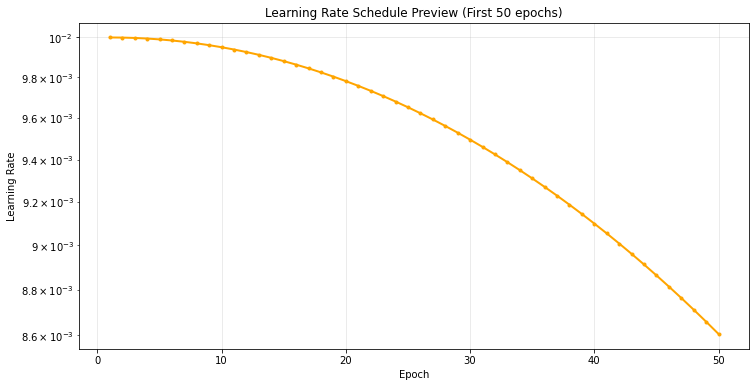

Initial LR: 0.010000
LR after 50 epochs: 0.008605
Final LR (after 200 epochs): 0.000100


In [59]:
# Preview the learning rate schedule
print("Learning Rate Schedule Preview:")
print("="*50)

# Create a preview of how LR will change over epochs
preview_epochs = 50  # Show first 50 epochs as preview
preview_lrs = []

# Create a temporary scheduler for preview
temp_optimizer = optim.Adam(model.parameters(), lr=LR)
temp_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(temp_optimizer, T_max=200, eta_min=0.0001)

for epoch in range(preview_epochs):
    preview_lrs.append(temp_scheduler.get_last_lr()[0])
    temp_scheduler.step()

# Plot preview
plt.figure(figsize=(12, 6))
plt.plot(range(1, preview_epochs + 1), preview_lrs, 'orange', linewidth=2, marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title(f'Learning Rate Schedule Preview (First {preview_epochs} epochs)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial LR: {preview_lrs[0]:.6f}")
print(f"LR after {preview_epochs} epochs: {preview_lrs[-1]:.6f}")
print(f"Final LR (after 200 epochs): 0.000100")
print("="*50)

# **Utils 🧰**

In [60]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [61]:
class EarlyStopping:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, min_delta=0, restore_best_weights=True, verbose=True):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
                            Default: 7
            min_delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                              Default: 0
            restore_best_weights (bool): Whether to restore model weights from the epoch with the best value
            verbose (bool): If True, prints a message for each validation loss improvement. 
                           Default: True
        """
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.verbose = verbose
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_state = None
        
    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            if self.verbose:
                print(f'✅ Validation loss improved from {self.best_loss:.6f} to {val_loss:.6f}')
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                # Save the best model state
                self.best_model_state = model.state_dict().copy()
        else:
            self.counter += 1
            if self.verbose:
                print(f'⚠️  EarlyStopping counter: {self.counter} out of {self.patience}')
            
            if self.counter >= self.patience:
                self.early_stop = True
                if self.restore_best_weights and self.best_model_state is not None:
                    if self.verbose:
                        print('🔄 Restoring best model weights...')
                    model.load_state_dict(self.best_model_state)
                if self.verbose:
                    print(f'🛑 Early stopping triggered! Best validation loss: {self.best_loss:.6f}')
        
        return self.early_stop

In [62]:
# Test Early Stopping (Optional - Remove if not needed)
def test_early_stopping():
    """Test the early stopping mechanism with simulated losses"""
    print("🧪 Testing Early Stopping Mechanism:")
    print("="*50)
    
    # Create a dummy model for testing
    dummy_model = UNetCompact()
    test_early_stopping = EarlyStopping(patience=3, min_delta=0.01, verbose=True)
    
    # Simulate some loss values (decreasing then plateauing)
    simulated_losses = [1.0, 0.8, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65]
    
    for i, loss in enumerate(simulated_losses):
        print(f"Epoch {i+1}: Validation Loss = {loss:.3f}")
        should_stop = test_early_stopping(loss, dummy_model)
        if should_stop:
            print(f"Early stopping would trigger at epoch {i+1}")
            break
        print()
    
    print("="*50)

# Uncomment the line below to test early stopping
# test_early_stopping()

# **Functions** 🧮

In [63]:
def train_one_epoch(model, train_loader, loss_fn, optimizer, epoch=None):
    model.train()
    loss_train = AverageMeter()
    acc_train = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(DEVICE)
    
    with tqdm(train_loader, unit="batch") as tepoch:
        for inputs, targets in tepoch:
            if epoch is not None:
                tepoch.set_description(f"Epoch {epoch}")
            
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)

            loss.backward()
            optimizer.step()

            pred_labels = outputs.argmax(dim=1)
            loss_train.update(loss.item())
            acc_train(pred_labels, targets)
            tepoch.set_postfix(
                loss=loss_train.avg,
                accuracy=100.0 * acc_train.compute().item()
            )
    
    return model, loss_train.avg, acc_train.compute().item()

In [64]:
def validation(model, test_loader, loss_fn):
    model.eval()
    
    with torch.no_grad():
        loss_valid = AverageMeter()
        acc_valid = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(DEVICE)

        iou_scores = []
        dice_scores = []

        for inputs, targets in test_loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)

            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            pred_labels = outputs.argmax(dim=1)
            batch_metrics = collect_line_metrics(pred_labels, targets)

            iou_scores.extend(batch_metrics['iou'])
            dice_scores.extend(batch_metrics['dice'])
            loss_valid.update(loss.item())
            acc_valid(pred_labels, targets)

    mean_iou = sum(iou_scores) / len(iou_scores) if iou_scores else 0
    mean_dice = sum(dice_scores) / len(dice_scores) if dice_scores else 0

    return loss_valid.avg, acc_valid.compute().item(), mean_iou, mean_dice

In [65]:
loss_train_hist = []
loss_valid_hist = []

acc_train_hist = []
acc_valid_hist = []

# Add new metric history lists
iou_valid_hist = []
dice_valid_hist = []

best_loss_valid = torch.inf
epoch_counter = 0

# Initialize Early Stopping with 10 epochs patience
early_stopping = EarlyStopping(patience=50, min_delta=0, verbose=True)
print("🛑 Early Stopping initialized with patience = 10 epochs")

🛑 Early Stopping initialized with patience = 10 epochs


In [66]:
num_epochs = 400

# Track learning rate changes
lr_hist = []

for epoch in range(num_epochs):
    print(f"\n{'='*60}")
    print(f"EPOCH {epoch + 1}/{num_epochs}")
    print(f"{'='*60}")
    
    # Get current learning rate
    current_lr = scheduler.get_last_lr()[0]
    lr_hist.append(current_lr)
    print(f"Current Learning Rate: {current_lr:.6f}")

    for _ in range(1):
        # Train
        model, loss_train, acc_train = train_one_epoch(model, 
                                                    train_loader, 
                                                    criterion, 
                                                    optimizer,
                                                    epoch + 1)
    
    # Main validation (existing test_loader)
    loss_valid, acc_valid, iou_valid, dice_valid = validation(model,
                                                              test_loader,
                                                              criterion)
    
    # Store main validation metrics
    loss_train_hist.append(loss_train)
    loss_valid_hist.append(loss_valid)
    acc_train_hist.append(acc_train)
    acc_valid_hist.append(acc_valid)
    iou_valid_hist.append(iou_valid)
    dice_valid_hist.append(dice_valid)
    
    
    # Save best model based on main validation loss
    if loss_valid < best_loss_valid:
        torch.save(model, 'Generalized_dataset.pt')
        best_loss_valid = loss_valid
        print('\n🎯 Best Model Saved!')
    
    # Print comprehensive results
    print(f"\n--- Epoch {epoch + 1} Results ---")
    print(f"Training   - Loss: {loss_train:.4f}, Acc: {acc_train:.4f}")
    print(f"Main Valid - Loss: {loss_valid:.4f}, Acc: {acc_valid:.4f}, IoU: {iou_valid:.4f}, Dice: {dice_valid:.4f}")
    
   
    early_stopping(loss_valid, model)

    
    # Update learning rate scheduler (IMPORTANT!)
    # scheduler.step()
    
    epoch_counter += 1

print(f"\n{'='*60}")
if early_stopping.early_stop:
    print("🛑 TRAINING STOPPED EARLY!")
    print(f"Best validation loss: {early_stopping.best_loss:.6f}")
    print(f"Stopped at epoch: {epoch_counter}")
else:
    print("TRAINING COMPLETED!")
print(f"{'='*60}")

  0%|          | 0/250 [00:00<?, ?batch/s]


EPOCH 1/400
Current Learning Rate: 0.010000


Epoch 1:   0%|          | 0/250 [00:08<?, ?batch/s]


OutOfMemoryError: Caught OutOfMemoryError in replica 0 on device 0.
Original Traceback (most recent call last):
  File "/users/fs2/rzarza/anaconda3/lib/python3.8/site-packages/torch/nn/parallel/parallel_apply.py", line 84, in _worker
    output = module(*input, **kwargs)
  File "/users/fs2/rzarza/anaconda3/lib/python3.8/site-packages/torch/nn/modules/module.py", line 1553, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/users/fs2/rzarza/anaconda3/lib/python3.8/site-packages/torch/nn/modules/module.py", line 1562, in _call_impl
    return forward_call(*args, **kwargs)
  File "<ipython-input-48-d177fc9375a8>", line 44, in forward
    e3 = self.enc3(self.pool2(e2))
  File "/users/fs2/rzarza/anaconda3/lib/python3.8/site-packages/torch/nn/modules/module.py", line 1553, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/users/fs2/rzarza/anaconda3/lib/python3.8/site-packages/torch/nn/modules/module.py", line 1562, in _call_impl
    return for

In [ ]:
model = torch.load('Generalized_dataset.pt', weights_only=False)
print("Loaded multiclass checkpoint from Generalized_dataset.pt")


In [ ]:
# Freeze all layers except the final output layer
for name, param in model.named_parameters():
    param.requires_grad = False
    if "outc" in name:
        param.requires_grad = True
    if "dec1" in name:
        param.requires_grad = True

# Verify which parameters are frozen
for name, param in model.named_parameters():
    print(f"{name}: {'Frozen' if not param.requires_grad else 'Trainable'}")

# **Plot**

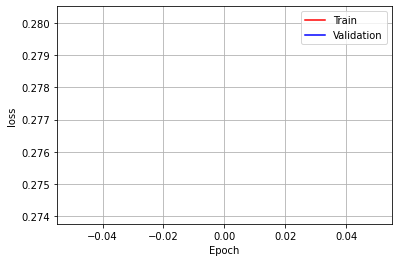

In [31]:
plt.plot(range(epoch_counter), loss_train_hist, 'r-', label='Train')
plt.plot(range(epoch_counter), loss_valid_hist, 'b-', label='Validation')

plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid(True)
plt.legend()

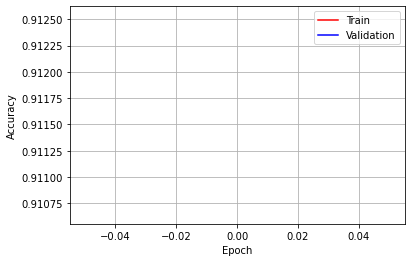

In [32]:
plt.plot(range(epoch_counter), acc_train_hist, 'r-', label='Train')
plt.plot(range(epoch_counter), acc_valid_hist, 'b-', label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

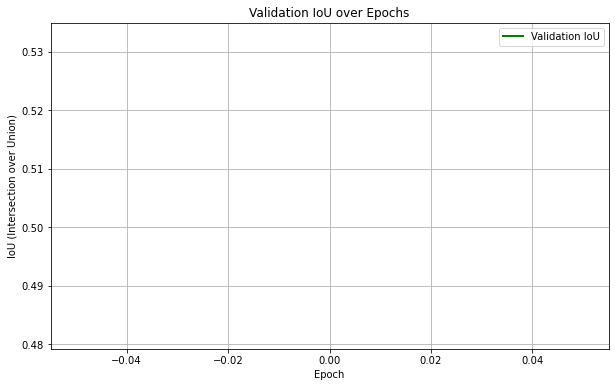

In [33]:
# Plot IoU over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(epoch_counter), iou_valid_hist, 'g-', label='Validation IoU', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('IoU (Intersection over Union)')
plt.title('Validation IoU over Epochs')
plt.grid(True)
plt.legend()
plt.show()

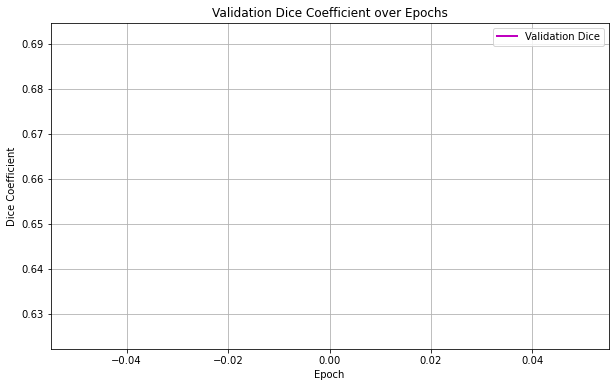

In [34]:
# Plot Dice coefficient over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(epoch_counter), dice_valid_hist, 'm-', label='Validation Dice', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.title('Validation Dice Coefficient over Epochs')
plt.grid(True)
plt.legend()
plt.show()

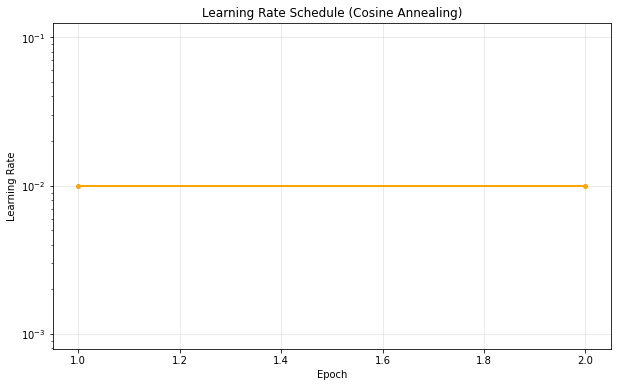

Learning Rate:
  Initial: 0.010000
  Final:   0.010000
  Range:   0.010000 → 0.010000


In [35]:
# Plot Learning Rate Schedule
if 'lr_hist' in locals() and len(lr_hist) > 0:
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(lr_hist) + 1), lr_hist, 'orange', linewidth=2, marker='o', markersize=4)
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Schedule (Cosine Annealing)')
    plt.yscale('log')  # Use log scale to better visualize the decay
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Learning Rate:")
    print(f"  Initial: {lr_hist[0]:.6f}")
    print(f"  Final:   {lr_hist[-1]:.6f}")
    print(f"  Range:   {lr_hist[0]:.6f} → {lr_hist[-1]:.6f}")
else:
    print("No learning rate history available to plot")

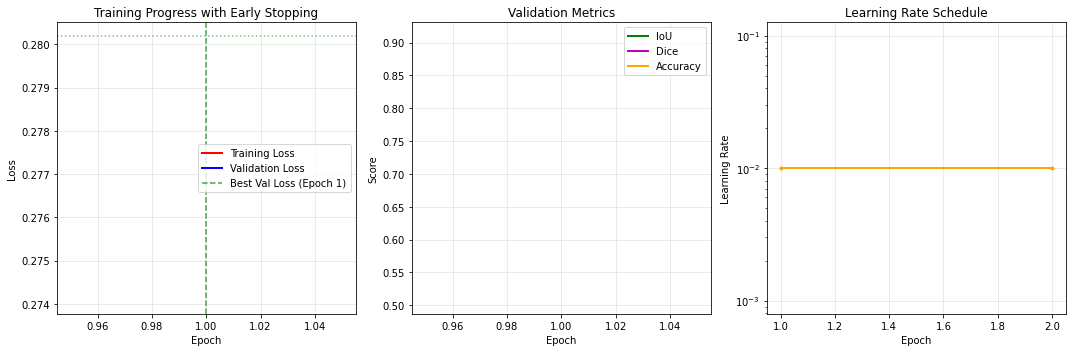


🛑 Early Stopping Summary:
   Patience: 50 epochs
   Min Delta: 0
   Best Validation Loss: 0.280201
   Early Stop Triggered: No


In [36]:
# Plot Training Progress with Early Stopping Information
if epoch_counter > 0:
    plt.figure(figsize=(15, 5))
    
    # Loss plot
    plt.subplot(1, 3, 1)
    plt.plot(range(1, epoch_counter + 1), loss_train_hist, 'r-', label='Training Loss', linewidth=2)
    plt.plot(range(1, epoch_counter + 1), loss_valid_hist, 'b-', label='Validation Loss', linewidth=2)
    
    # Mark best validation loss
    if 'early_stopping' in locals():
        best_epoch = loss_valid_hist.index(early_stopping.best_loss) + 1
        plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Val Loss (Epoch {best_epoch})')
        plt.axhline(y=early_stopping.best_loss, color='green', linestyle=':', alpha=0.5)
        
        # Mark early stopping point if triggered
        if early_stopping.early_stop:
            plt.axvline(x=epoch_counter, color='red', linestyle='--', alpha=0.7, label=f'Early Stop (Epoch {epoch_counter})')
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Progress with Early Stopping')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Validation metrics plot
    plt.subplot(1, 3, 2)
    plt.plot(range(1, epoch_counter + 1), iou_valid_hist, 'g-', label='IoU', linewidth=2)
    plt.plot(range(1, epoch_counter + 1), dice_valid_hist, 'm-', label='Dice', linewidth=2)
    plt.plot(range(1, epoch_counter + 1), acc_valid_hist, 'orange', label='Accuracy', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title('Validation Metrics')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Learning rate plot
    plt.subplot(1, 3, 3)
    if 'lr_hist' in locals() and len(lr_hist) > 0:
        plt.plot(range(1, len(lr_hist) + 1), lr_hist, 'orange', linewidth=2, marker='o', markersize=3)
        plt.yscale('log')
        plt.xlabel('Epoch')
        plt.ylabel('Learning Rate')
        plt.title('Learning Rate Schedule')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print early stopping summary
    if 'early_stopping' in locals():
        print(f"\n🛑 Early Stopping Summary:")
        print(f"   Patience: {early_stopping.patience} epochs")
        print(f"   Min Delta: {early_stopping.min_delta}")
        print(f"   Best Validation Loss: {early_stopping.best_loss:.6f}")
        print(f"   Early Stop Triggered: {'Yes' if early_stopping.early_stop else 'No'}")
        if early_stopping.early_stop:
            print(f"   Stopped at Epoch: {epoch_counter}")
            print(f"   Epochs without improvement: {early_stopping.counter}")
else:
    print("No training data available to plot")

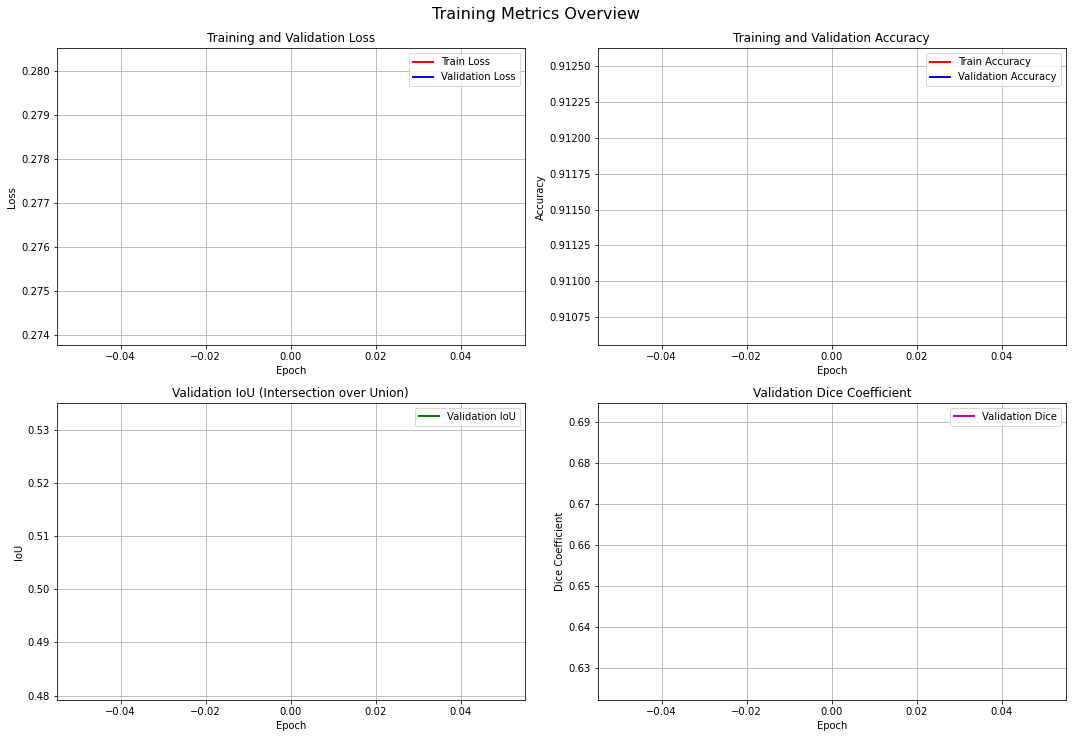

FINAL TRAINING METRICS SUMMARY
Final Training Loss:     0.2741
Final Validation Loss:   0.2802
Final Training Accuracy: 0.9125
Final Validation Accuracy: 0.9106
Final Validation IoU:    0.5071
Final Validation Dice:   0.6584
BEST VALIDATION METRICS
Best Validation Accuracy: 0.9106 (Epoch 1)
Best Validation IoU:      0.5071 (Epoch 1)
Best Validation Dice:     0.6584 (Epoch 1)


In [37]:
# Combined metrics plot
plt.figure(figsize=(15, 10))

# Plot 1: Loss
plt.subplot(2, 2, 1)
plt.plot(range(epoch_counter), loss_train_hist, 'r-', label='Train Loss', linewidth=2)
plt.plot(range(epoch_counter), loss_valid_hist, 'b-', label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.grid(True)
plt.legend()

# Plot 2: Accuracy
plt.subplot(2, 2, 2)
plt.plot(range(epoch_counter), acc_train_hist, 'r-', label='Train Accuracy', linewidth=2)
plt.plot(range(epoch_counter), acc_valid_hist, 'b-', label='Validation Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.grid(True)
plt.legend()

# Plot 3: IoU
plt.subplot(2, 2, 3)
plt.plot(range(epoch_counter), iou_valid_hist, 'g-', label='Validation IoU', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.title('Validation IoU (Intersection over Union)')
plt.grid(True)
plt.legend()

# Plot 4: Dice
plt.subplot(2, 2, 4)
plt.plot(range(epoch_counter), dice_valid_hist, 'm-', label='Validation Dice', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.title('Validation Dice Coefficient')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.suptitle('Training Metrics Overview', fontsize=16, y=1.02)
plt.show()

# Print final metrics summary
if epoch_counter > 0:
    print("="*60)
    print("FINAL TRAINING METRICS SUMMARY")
    print("="*60)
    print(f"Final Training Loss:     {loss_train_hist[-1]:.4f}")
    print(f"Final Validation Loss:   {loss_valid_hist[-1]:.4f}")
    print(f"Final Training Accuracy: {acc_train_hist[-1]:.4f}")
    print(f"Final Validation Accuracy: {acc_valid_hist[-1]:.4f}")
    print(f"Final Validation IoU:    {iou_valid_hist[-1]:.4f}")
    print(f"Final Validation Dice:   {dice_valid_hist[-1]:.4f}")
    print("="*60)
    
    # Best metrics
    best_val_acc = max(acc_valid_hist)
    best_val_iou = max(iou_valid_hist)
    best_val_dice = max(dice_valid_hist)
    
    print("BEST VALIDATION METRICS")
    print("="*60)
    print(f"Best Validation Accuracy: {best_val_acc:.4f} (Epoch {acc_valid_hist.index(best_val_acc) + 1})")
    print(f"Best Validation IoU:      {best_val_iou:.4f} (Epoch {iou_valid_hist.index(best_val_iou) + 1})")
    print(f"Best Validation Dice:     {best_val_dice:.4f} (Epoch {dice_valid_hist.index(best_val_dice) + 1})")
    print("="*60)

In [38]:
def plot_multi_dataset_validation_results():
    """
    Plot comprehensive validation results for all datasets
    """
    if not multi_val_metrics or epoch_counter == 0:
        print("No multi-dataset validation metrics to plot")
        return
    
    # Set up the plot
    available_datasets = [name for name in multi_val_metrics.keys() if len(multi_val_metrics[name]['loss']) > 0]
    
    if not available_datasets:
        print("No validation data available for plotting")
        return
    
    # Create a comprehensive plot
    fig = plt.figure(figsize=(20, 15))
    
    # Define colors for each dataset
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
    dataset_colors = {dataset: colors[i % len(colors)] for i, dataset in enumerate(available_datasets)}
    
    # 1. Loss comparison across all datasets
    plt.subplot(3, 3, 1)
    plt.plot(range(epoch_counter), loss_train_hist, 'black', label='Training', linewidth=2)
    plt.plot(range(epoch_counter), loss_valid_hist, 'gray', label='Main Valid', linewidth=2)
    for dataset_name in available_datasets:
        plt.plot(range(epoch_counter), multi_val_metrics[dataset_name]['loss'], 
                color=dataset_colors[dataset_name], label=dataset_name, linewidth=1.5)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Comparison - All Datasets')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # 2. IoU comparison
    plt.subplot(3, 3, 2)
    plt.plot(range(epoch_counter), iou_valid_hist, 'gray', label='Main Valid', linewidth=2)
    for dataset_name in available_datasets:
        plt.plot(range(epoch_counter), multi_val_metrics[dataset_name]['iou'], 
                color=dataset_colors[dataset_name], label=dataset_name, linewidth=1.5)
    plt.xlabel('Epoch')
    plt.ylabel('IoU')
    plt.title('IoU Comparison - All Datasets')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # 3. Dice comparison
    plt.subplot(3, 3, 3)
    plt.plot(range(epoch_counter), dice_valid_hist, 'gray', label='Main Valid', linewidth=2)
    for dataset_name in available_datasets:
        plt.plot(range(epoch_counter), multi_val_metrics[dataset_name]['dice'], 
                color=dataset_colors[dataset_name], label=dataset_name, linewidth=1.5)
    plt.xlabel('Epoch')
    plt.ylabel('Dice Coefficient')
    plt.title('Dice Comparison - All Datasets')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # 4. Accuracy comparison
    plt.subplot(3, 3, 4)
    plt.plot(range(epoch_counter), acc_train_hist, 'black', label='Training', linewidth=2)
    plt.plot(range(epoch_counter), acc_valid_hist, 'gray', label='Main Valid', linewidth=2)
    for dataset_name in available_datasets:
        plt.plot(range(epoch_counter), multi_val_metrics[dataset_name]['accuracy'], 
                color=dataset_colors[dataset_name], label=dataset_name, linewidth=1.5)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Comparison - All Datasets')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # 5. Precision comparison
    plt.subplot(3, 3, 5)
    for dataset_name in available_datasets:
        plt.plot(range(epoch_counter), multi_val_metrics[dataset_name]['precision'], 
                color=dataset_colors[dataset_name], label=dataset_name, linewidth=1.5)
    plt.xlabel('Epoch')
    plt.ylabel('Precision')
    plt.title('Precision Comparison - All Datasets')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # 6. Recall comparison
    plt.subplot(3, 3, 6)
    for dataset_name in available_datasets:
        plt.plot(range(epoch_counter), multi_val_metrics[dataset_name]['recall'], 
                color=dataset_colors[dataset_name], label=dataset_name, linewidth=1.5)
    plt.xlabel('Epoch')
    plt.ylabel('Recall')
    plt.title('Recall Comparison - All Datasets')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # 7. F1-Score (calculated from precision and recall)
    plt.subplot(3, 3, 7)
    for dataset_name in available_datasets:
        precision_vals = multi_val_metrics[dataset_name]['precision']
        recall_vals = multi_val_metrics[dataset_name]['recall']
        f1_vals = [2 * (p * r) / (p + r + 1e-7) for p, r in zip(precision_vals, recall_vals)]
        plt.plot(range(epoch_counter), f1_vals, 
                color=dataset_colors[dataset_name], label=dataset_name, linewidth=1.5)
    plt.xlabel('Epoch')
    plt.ylabel('F1-Score')
    plt.title('F1-Score Comparison - All Datasets')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # 8. Final metrics bar chart
    plt.subplot(3, 3, 8)
    if epoch_counter > 0:
        final_metrics = ['IoU', 'Dice', 'Accuracy', 'Precision', 'Recall']
        x_pos = np.arange(len(final_metrics))
        width = 0.15
        
        for i, dataset_name in enumerate(available_datasets):
            final_values = [
                multi_val_metrics[dataset_name]['iou'][-1],
                multi_val_metrics[dataset_name]['dice'][-1],
                multi_val_metrics[dataset_name]['accuracy'][-1],
                multi_val_metrics[dataset_name]['precision'][-1],
                multi_val_metrics[dataset_name]['recall'][-1]
            ]
            plt.bar(x_pos + i * width, final_values, width, 
                   label=dataset_name, color=dataset_colors[dataset_name], alpha=0.8)
        
        plt.xlabel('Metrics')
        plt.ylabel('Score')
        plt.title('Final Metrics Comparison')
        plt.xticks(x_pos + width * (len(available_datasets) - 1) / 2, final_metrics)
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    # 9. Metrics summary table
    plt.subplot(3, 3, 9)
    plt.axis('off')
    
    if epoch_counter > 0:
        # Create summary table
        table_data = []
        headers = ['Dataset', 'Loss', 'IoU', 'Dice', 'Accuracy', 'Precision', 'Recall']
        
        # Add main validation
        table_data.append(['Main Valid', f"{loss_valid_hist[-1]:.3f}", f"{iou_valid_hist[-1]:.3f}", 
                          f"{dice_valid_hist[-1]:.3f}", f"{acc_valid_hist[-1]:.3f}", "N/A", "N/A"])
        
        # Add multi-dataset validation
        for dataset_name in available_datasets:
            row = [
                dataset_name,
                f"{multi_val_metrics[dataset_name]['loss'][-1]:.3f}",
                f"{multi_val_metrics[dataset_name]['iou'][-1]:.3f}",
                f"{multi_val_metrics[dataset_name]['dice'][-1]:.3f}",
                f"{multi_val_metrics[dataset_name]['accuracy'][-1]:.3f}",
                f"{multi_val_metrics[dataset_name]['precision'][-1]:.3f}",
                f"{multi_val_metrics[dataset_name]['recall'][-1]:.3f}"
            ]
            table_data.append(row)
        
        table = plt.table(cellText=table_data, colLabels=headers, 
                         cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
        table.auto_set_font_size(False)
        table.set_fontsize(8)
        table.scale(1, 1.5)
        plt.title('Final Metrics Summary', pad=20)
    
    plt.tight_layout()
    plt.savefig('img.png')
    plt.show()

# Call the plotting function
print("Plotting comprehensive validation results...")
plot_multi_dataset_validation_results()

Plotting comprehensive validation results...


NameError: name 'multi_val_metrics' is not defined

In [ ]:
def plot_individual_dataset_metrics():
    """
    Create detailed plots for each validation dataset individually
    """
    if not multi_val_metrics or epoch_counter == 0:
        print("No multi-dataset validation metrics to plot")
        return
    
    available_datasets = [name for name in multi_val_metrics.keys() if len(multi_val_metrics[name]['loss']) > 0]
    
    if not available_datasets:
        print("No validation data available for plotting")
        return
    
    for dataset_name in available_datasets:
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle(f'Detailed Metrics for {dataset_name}', fontsize=16, fontweight='bold')
        
        # Loss
        axes[0, 0].plot(range(epoch_counter), multi_val_metrics[dataset_name]['loss'], 'b-', linewidth=2)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Validation Loss')
        axes[0, 0].grid(True, alpha=0.3)
        
        # IoU
        axes[0, 1].plot(range(epoch_counter), multi_val_metrics[dataset_name]['iou'], 'g-', linewidth=2)
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('IoU')
        axes[0, 1].set_title('Intersection over Union')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Dice
        axes[0, 2].plot(range(epoch_counter), multi_val_metrics[dataset_name]['dice'], 'm-', linewidth=2)
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('Dice Coefficient')
        axes[0, 2].set_title('Dice Coefficient')
        axes[0, 2].grid(True, alpha=0.3)
        
        # Accuracy
        axes[1, 0].plot(range(epoch_counter), multi_val_metrics[dataset_name]['accuracy'], 'r-', linewidth=2)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Accuracy')
        axes[1, 0].set_title('Accuracy')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Precision
        axes[1, 1].plot(range(epoch_counter), multi_val_metrics[dataset_name]['precision'], 'orange', linewidth=2)
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Precision')
        axes[1, 1].set_title('Precision')
        axes[1, 1].grid(True, alpha=0.3)
        
        # Recall
        axes[1, 2].plot(range(epoch_counter), multi_val_metrics[dataset_name]['recall'], 'purple', linewidth=2)
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('Recall')
        axes[1, 2].set_title('Recall')
        axes[1, 2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics for this dataset
        if epoch_counter > 0:
            print(f"\n{dataset_name} - Final Metrics Summary:")
            print(f"  Loss:      {multi_val_metrics[dataset_name]['loss'][-1]:.4f}")
            print(f"  IoU:       {multi_val_metrics[dataset_name]['iou'][-1]:.4f}")
            print(f"  Dice:      {multi_val_metrics[dataset_name]['dice'][-1]:.4f}")
            print(f"  Accuracy:  {multi_val_metrics[dataset_name]['accuracy'][-1]:.4f}")
            print(f"  Precision: {multi_val_metrics[dataset_name]['precision'][-1]:.4f}")
            print(f"  Recall:    {multi_val_metrics[dataset_name]['recall'][-1]:.4f}")
            
            # Calculate F1-Score
            p = multi_val_metrics[dataset_name]['precision'][-1]
            r = multi_val_metrics[dataset_name]['recall'][-1]
            f1 = 2 * (p * r) / (p + r + 1e-7)
            print(f"  F1-Score:  {f1:.4f}")
            print("-" * 40)

# Call the individual plotting function
print("Creating detailed plots for each validation dataset...")
plot_individual_dataset_metrics()

In [57]:
def print_comprehensive_training_summary():
    """
    Print a comprehensive summary of training results across all validation datasets
    """
    print("\n" + "="*80)
    print("🎯 COMPREHENSIVE TRAINING SUMMARY")
    print("="*80)
    
    if epoch_counter == 0:
        print("No training data available.")
        return
    
    # Training summary
    print(f"\n📊 TRAINING OVERVIEW:")
    print(f"  Total Epochs:           {epoch_counter}")
    print(f"  Final Training Loss:    {loss_train_hist[-1]:.4f}")
    print(f"  Final Training Accuracy: {acc_train_hist[-1]:.4f}")
    print(f"  Best Validation Loss:   {best_loss_valid:.4f}")
    
    # Main validation summary
    print(f"\n🔍 MAIN VALIDATION RESULTS:")
    print(f"  Final Loss:             {loss_valid_hist[-1]:.4f}")
    print(f"  Final Accuracy:         {acc_valid_hist[-1]:.4f}")
    print(f"  Final IoU:              {iou_valid_hist[-1]:.4f}")
    print(f"  Final Dice:             {dice_valid_hist[-1]:.4f}")
    
    # Multi-dataset validation summary
    available_datasets = [name for name in multi_val_metrics.keys() if len(multi_val_metrics[name]['loss']) > 0]
    
    if available_datasets:
        print(f"\n📈 MULTI-DATASET VALIDATION RESULTS:")
        print(f"{'Dataset':<15} {'Loss':<8} {'IoU':<8} {'Dice':<8} {'Acc':<8} {'Prec':<8} {'Recall':<8} {'F1':<8}")
        print("-" * 80)
        
        best_metrics = {
            'iou': {'value': 0, 'dataset': ''},
            'dice': {'value': 0, 'dataset': ''},
            'accuracy': {'value': 0, 'dataset': ''},
            'precision': {'value': 0, 'dataset': ''},
            'recall': {'value': 0, 'dataset': ''},
            'f1': {'value': 0, 'dataset': ''}
        }
        
        for dataset_name in available_datasets:
            metrics = multi_val_metrics[dataset_name]
            final_metrics = {
                'loss': metrics['loss'][-1],
                'iou': metrics['iou'][-1],
                'dice': metrics['dice'][-1],
                'accuracy': metrics['accuracy'][-1],
                'precision': metrics['precision'][-1],
                'recall': metrics['recall'][-1]
            }
            
            # Calculate F1-Score
            f1 = 2 * (final_metrics['precision'] * final_metrics['recall']) / \
                 (final_metrics['precision'] + final_metrics['recall'] + 1e-7)
            final_metrics['f1'] = f1
            
            # Update best metrics
            for metric in ['iou', 'dice', 'accuracy', 'precision', 'recall', 'f1']:
                if final_metrics[metric] > best_metrics[metric]['value']:
                    best_metrics[metric]['value'] = final_metrics[metric]
                    best_metrics[metric]['dataset'] = dataset_name
            
            print(f"{dataset_name:<15} {final_metrics['loss']:<8.3f} {final_metrics['iou']:<8.3f} "
                  f"{final_metrics['dice']:<8.3f} {final_metrics['accuracy']:<8.3f} "
                  f"{final_metrics['precision']:<8.3f} {final_metrics['recall']:<8.3f} {final_metrics['f1']:<8.3f}")
        
        # Best performing datasets
        print(f"\n🏆 BEST PERFORMING DATASETS:")
        for metric, info in best_metrics.items():
            if info['value'] > 0:
                print(f"  Best {metric.upper():<9}: {info['dataset']:<15} ({info['value']:.4f})")
        
        # Model generalization analysis
        print(f"\n🧮 GENERALIZATION ANALYSIS:")
        iou_values = [multi_val_metrics[ds]['iou'][-1] for ds in available_datasets]
        dice_values = [multi_val_metrics[ds]['dice'][-1] for ds in available_datasets]
        
        iou_std = np.std(iou_values)
        dice_std = np.std(dice_values)
        iou_mean = np.mean(iou_values)
        dice_mean = np.mean(dice_values)
        
        print(f"  IoU  - Mean: {iou_mean:.4f}, Std: {iou_std:.4f}, CoV: {iou_std/iou_mean:.3f}")
        print(f"  Dice - Mean: {dice_mean:.4f}, Std: {dice_std:.4f}, CoV: {dice_std/dice_mean:.3f}")
        
        if iou_std < 0.1 and dice_std < 0.1:
            print("  ✅ Model shows good generalization across datasets (low variance)")
        elif iou_std < 0.2 and dice_std < 0.2:
            print("  ⚠️  Model shows moderate generalization across datasets")
        else:
            print("  ❌ Model shows poor generalization across datasets (high variance)")
    
    print("\n" + "="*80)

# Call the comprehensive summary
print_comprehensive_training_summary()


🎯 COMPREHENSIVE TRAINING SUMMARY

📊 TRAINING OVERVIEW:
  Total Epochs:           30
  Final Training Loss:    0.0330
  Final Training Accuracy: 0.9889
  Best Validation Loss:   0.0435

🔍 MAIN VALIDATION RESULTS:
  Final Loss:             0.0482
  Final Accuracy:         0.9877
  Final IoU:              0.6388
  Final Dice:             0.7353

📈 MULTI-DATASET VALIDATION RESULTS:
Dataset         Loss     IoU      Dice     Acc      Prec     Recall   F1      
--------------------------------------------------------------------------------
Bridge_Crack    0.161    0.287    0.421    0.936    0.333    0.736    0.459   
CFD_Data        0.042    0.374    0.531    0.985    0.535    0.582    0.558   
GOCrack150      0.253    0.140    0.237    0.938    0.436    0.180    0.255   
DRIVE           0.550    0.189    0.317    0.820    0.236    0.492    0.319   
Crack500        0.228    0.219    0.337    0.924    0.398    0.363    0.379   
CrackLS315      0.037    0.069    0.124    0.989    0.098    0.

In [28]:
# model = torch.load('model_trained_on_combined_dataset.pt', weights_only=False)

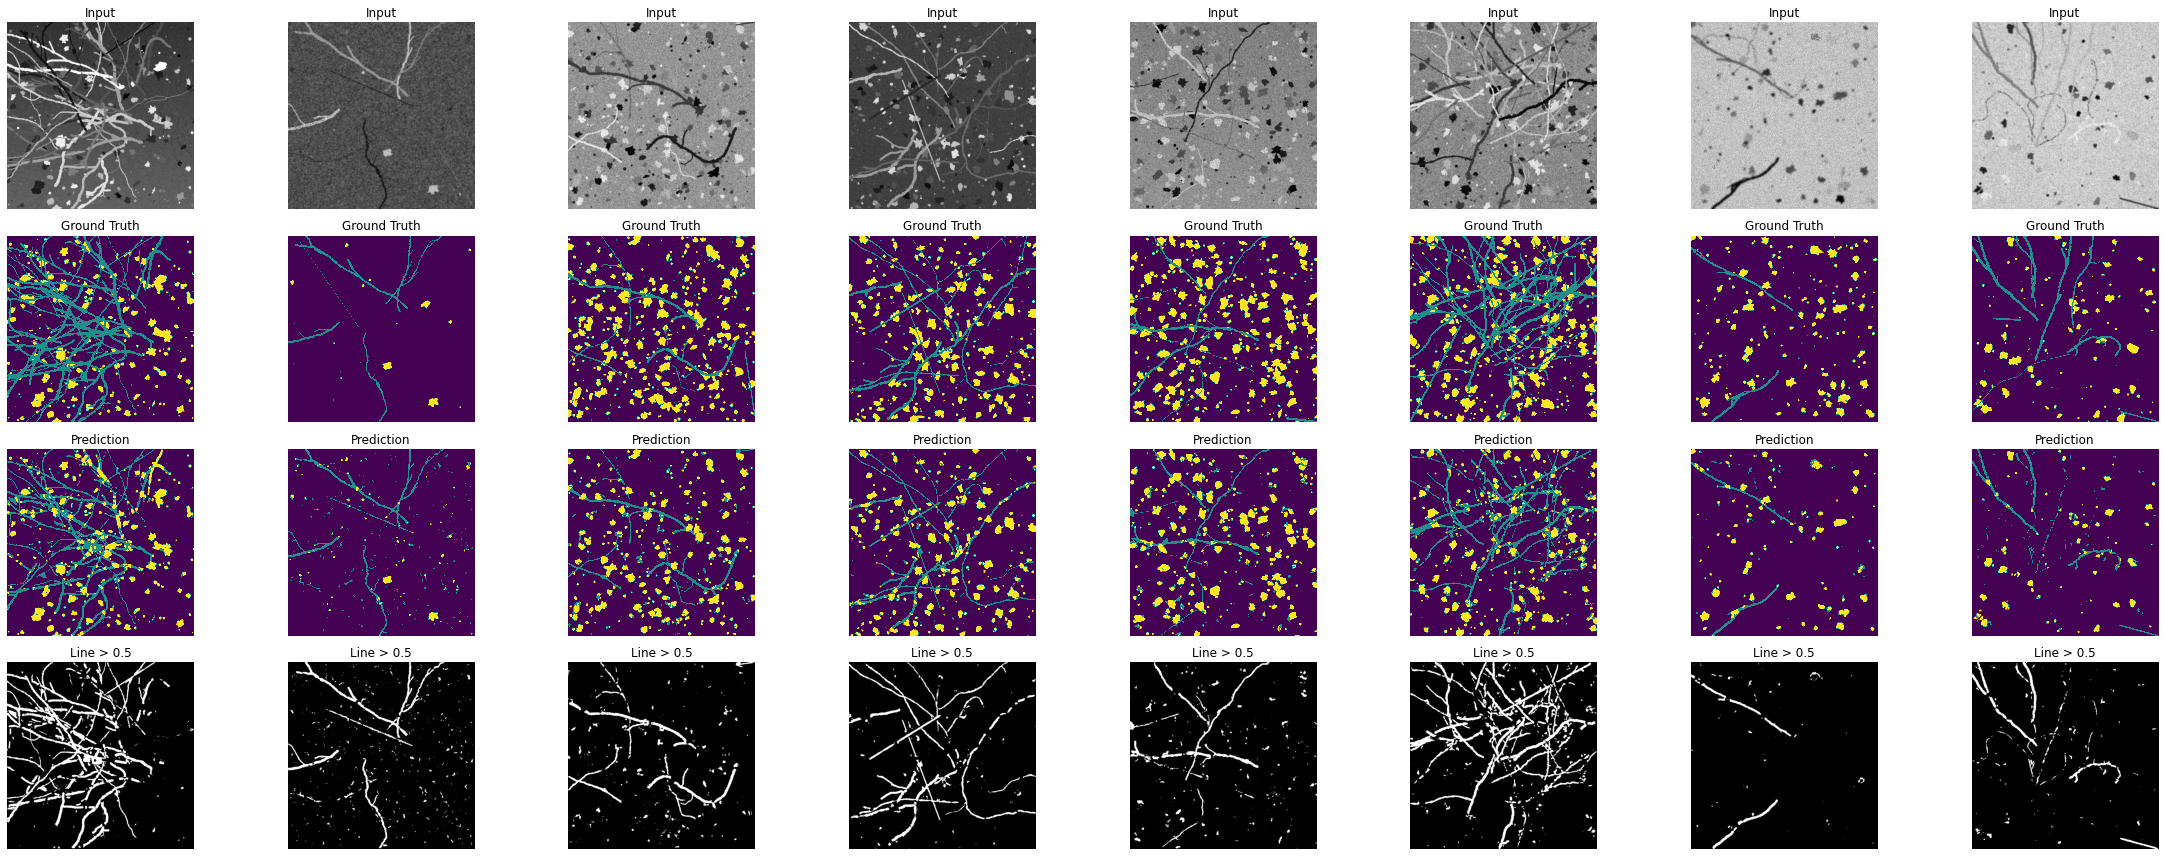

In [39]:
# Evaluation Function
def visualize_predictions(test_loader, threshold=None, max_items=None):
    model.eval()
    images, masks = next(iter(test_loader))
    images = images.to(DEVICE)
    
    with torch.no_grad():
        outputs = model(images)
        pred_labels = outputs.argmax(dim=1).cpu()
        line_probs = outputs.softmax(dim=1)[:, LINE_CLASS].cpu()

    images = images.cpu()
    masks = masks.cpu()
    num_items = min(images.size(0), max_items or BATCH_SIZE)
    use_threshold = threshold is not None and threshold != 0
    n_rows = 4 if use_threshold else 3
    cmap = plt.get_cmap('viridis', NUM_CLASSES)

    fig, axs = plt.subplots(n_rows, num_items, figsize=(4 * num_items, 3 * n_rows))
    if num_items == 1:
        axs = np.expand_dims(axs, axis=1)

    for i in range(num_items):
        axs[0, i].imshow(images[i].squeeze(), cmap='gray')
        axs[0, i].set_title('Input')
        axs[0, i].axis('off')

        axs[1, i].imshow(masks[i], cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
        axs[1, i].set_title('Ground Truth')
        axs[1, i].axis('off')

        axs[2, i].imshow(pred_labels[i], cmap=cmap, vmin=0, vmax=NUM_CLASSES - 1)
        axs[2, i].set_title('Prediction')
        axs[2, i].axis('off')

        if use_threshold:
            axs[3, i].imshow((line_probs[i] > threshold).float(), cmap='gray')
            axs[3, i].set_title(f'Line > {threshold}')
            axs[3, i].axis('off')

    plt.tight_layout()
    plt.show()

# Show results
visualize_predictions(test_loader, threshold=0.5)

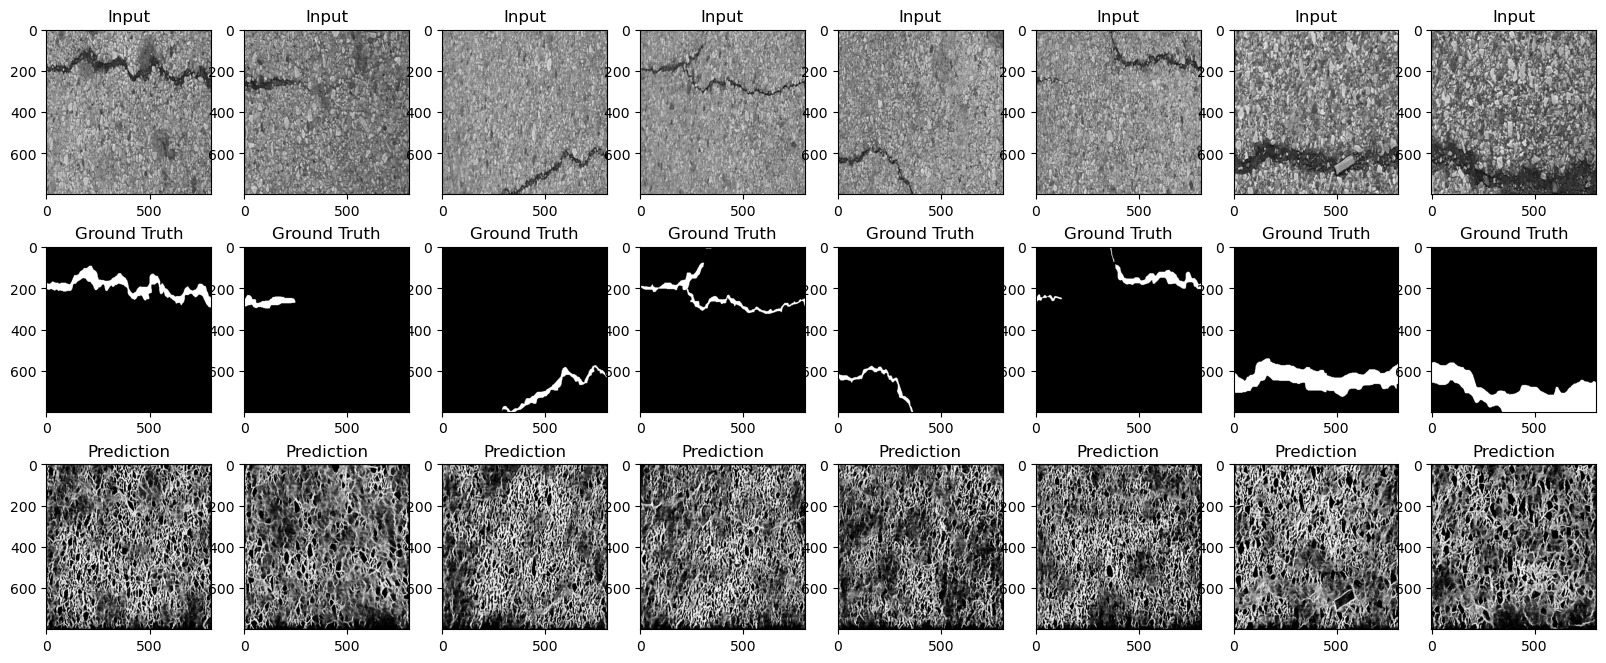

In [119]:
# visuallization function for multi-dataset validation #Bridge_Crack  #CFD_Data  #DRIVE
visualize_predictions(val_loaders['Crack500'])

(-0.5, 799.5, 799.5, -0.5)

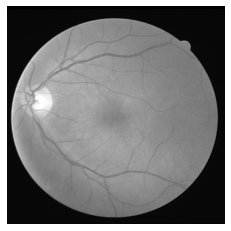

In [44]:
image = Image.open('/users/fs2/rzarza/Git/Crack_detection/archive/DRIVE/images_test/21_training.tif').convert("L")
image_size = 800
image = image.resize((image_size, image_size))
# image = liot(image, window_size=5)
import cv2
# image = cv2.GaussianBlur(np.array(image), (9, 9), sigmaX=2)
plt.imshow(image, cmap='gray')
plt.axis(False)
# output_path = "./../../../Rock_CT_images/1A-135k-Data_cropp/masks/11.png"
# plt.savefig(output_path, bbox_inches='tight', pad_inches=0)

In [45]:
# # Get the model output
# output = model(torch.Tensor(np.array(image)/255.0).unsqueeze(0).unsqueeze(0).to(DEVICE)).detach().cpu().squeeze()

# # Convert to 8-bit grayscale (0-255)
# output_np = (output.numpy() * 255).astype(np.uint8)

# # Resize to exact dimensions if needed
# output_img = Image.fromarray(output_np)
# output_img = output_img.resize((565, 584), Image.LANCZOS)
# output_img.save("output.png")

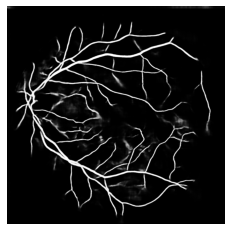

In [46]:
plt.imshow(model(torch.Tensor(np.array(image)/255.0).unsqueeze(0).unsqueeze(0).to(DEVICE)).detach().cpu().squeeze(), cmap='gray')
plt.axis(False)
output_path = "./out.png"
plt.savefig(output_path)

In [347]:
# torch.save(model, 'best_model_CFD_Dice_0.60.pt')

In [36]:
SIZE = 224
# Transforms
transform = transforms.Compose([
    transforms.Resize((SIZE,SIZE)),
    transforms.ToTensor()
])
dataset_name = 'CFD_Data' #"Bridge Crack Library" #'Concrete Crack Images for Classification' #'CFD_Data' #'GOCrack150'
VAL_IMG_DIR = f"./archive/{dataset_name}/images/"  # Replace with the image directory
VAL_MASK_DIR = f"./archive/{dataset_name}/masks/"    # Replace with the mask directory
val_dataset =  SegmentationDataset(VAL_IMG_DIR, VAL_MASK_DIR, transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

FileNotFoundError: [Errno 2] No such file or directory: './archive/CFD_Data/images/'

In [ ]:
# Load Model
# model = torch.load('big_model_with_nise_augmentation_FRUNET.pt', weights_only=False)
model.eval()

# Metrics
ious, dices, accuracies, precisions, recalls = [], [], [], [], []

def calculate_metrics(logits, target):
    pred_labels = logits.argmax(dim=0)
    target = target.squeeze(0) if target.dim() == 3 and target.size(0) == 1 else target
    
    pred_line = (pred_labels == LINE_CLASS).float()
    target_line = (target == LINE_CLASS).float()
    
    intersection = (pred_line * target_line).sum()
    union = pred_line.sum() + target_line.sum()
    true_positive = intersection
    false_positive = (pred_line * (1 - target_line)).sum()
    false_negative = ((1 - pred_line) * target_line).sum()
    
    dice = (2 * intersection) / (union + 1e-7)
    iou = intersection / (union - intersection + 1e-7)
    acc = (pred_labels == target).float().mean()
    precision = true_positive / (true_positive + false_positive + 1e-7)
    recall = true_positive / (true_positive + false_negative + 1e-7)

    return dice.item(), iou.item(), acc.item(), precision.item(), recall.item()

with torch.no_grad():
    for _, (images, masks) in enumerate(val_loader):
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        preds = model(images)

        for i in range(images.size(0)):
            dice, iou, acc, precision, recall = calculate_metrics(preds[i], masks[i])
            dices.append(dice)
            ious.append(iou)
            accuracies.append(acc)
            precisions.append(precision)
            recalls.append(recall)

# Print Metrics
print(f"Mean Dice: {np.mean(dices):.4f}")
print(f"Mean IoU: {np.mean(ious):.4f}")
print(f"Mean Accuracy: {np.mean(accuracies):.4f}")
print(f"Mean Precision: {np.mean(precisions):.4f}")
print(f"Mean Recall: {np.mean(recalls):.4f}")

NameError: name 'val_loader' is not defined

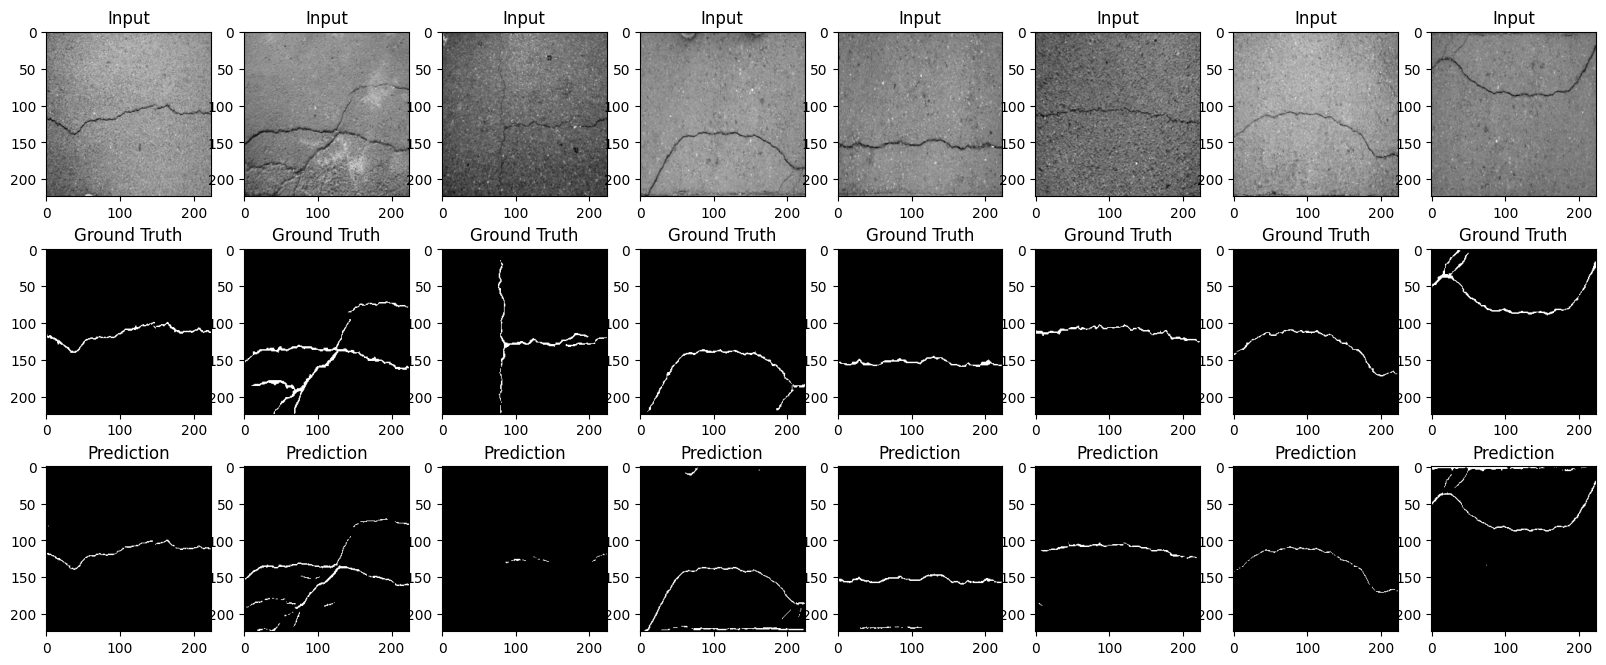

In [51]:
visualize_predictions(val_loader, 0.5)


LIOTFilter: Applies LIOT to ALL images with random window sizes (3, 5, 7, 9)


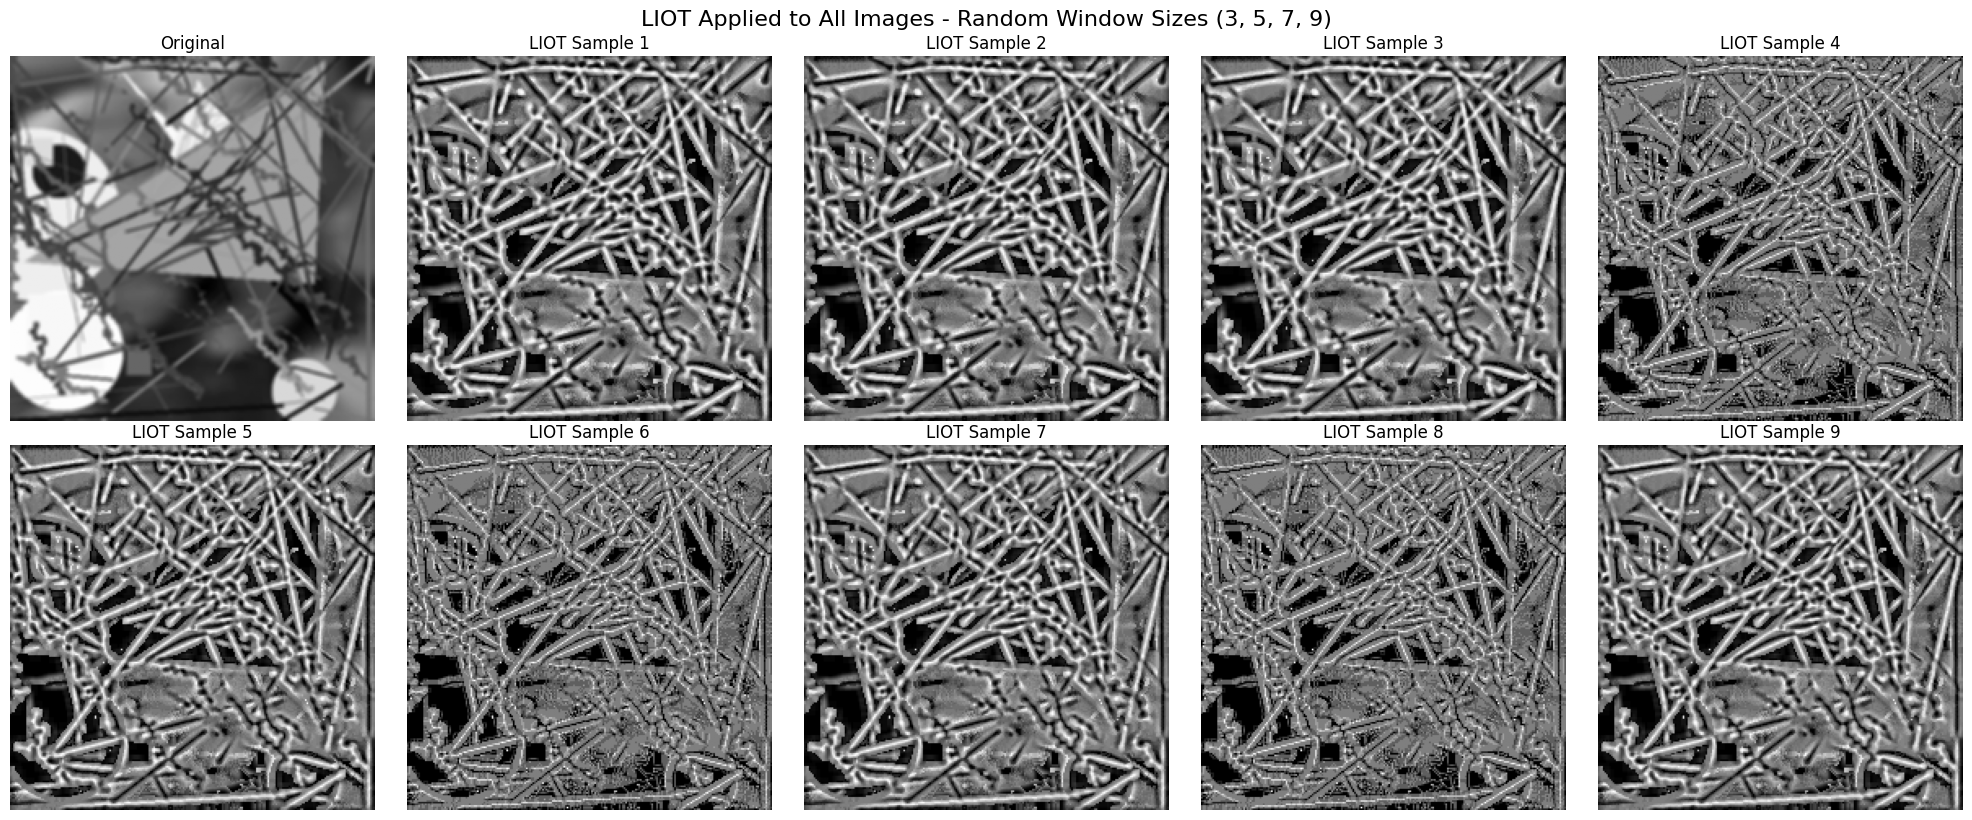

In [ ]:


# Test the LIOT filter
def test_liot_all_images():
    # Load a sample image
    sample_image_path = "/home/ramyar/Desktop/Github/Crack_detection/Data/images/0_000000000776.jpg"
    original_img = Image.open(sample_image_path).convert("L")
    original_img = original_img.resize((224, 224))
    
    liot_filter = LIOTFilter()
    
    # Generate multiple LIOT applications
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    # Show original
    axes[0].imshow(original_img, cmap='gray')
    axes[0].set_title('Original', fontsize=12)
    axes[0].axis('off')
    
    # Apply LIOT with different window sizes
    for i in range(1, 10):
        liot_img = liot_filter(original_img.copy())
        axes[i].imshow(liot_img, cmap='gray')
        axes[i].set_title(f'LIOT Sample {i}', fontsize=12)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.suptitle('LIOT Applied to All Images - Random Window Sizes (3, 5, 7, 9)', fontsize=16, y=1.02)
    plt.show()

print("LIOTFilter: Applies LIOT to ALL images with random window sizes (3, 5, 7, 9)")
test_liot_all_images()

Creating new dataset with LIOT applied to ALL images...
Dataset created successfully!
Training samples: 4000
Test samples: 1000
All images will have LIOT applied with random window sizes: 3, 5, 7, or 9

Visualizing training samples with LIOT applied:


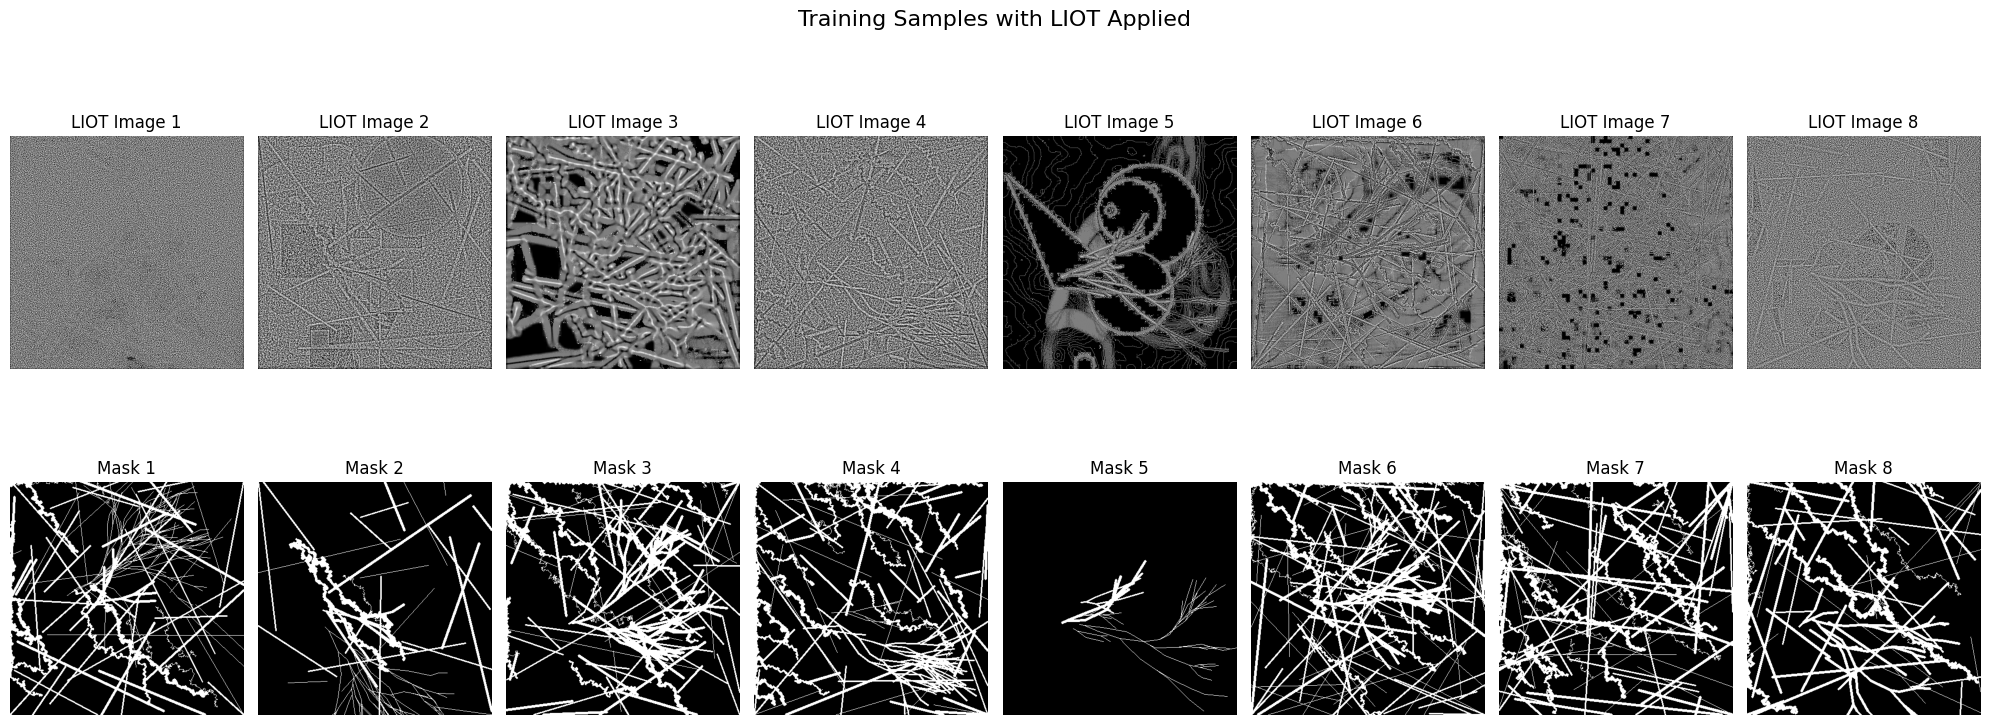

In [8]:
# Updated Dataset Configuration with LIOT applied to ALL images

# Transforms with LIOT filter applied to all images
transform_with_liot = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])

# LIOT filter that will be applied to all images
liot_filter = transforms.Compose([
    LIOTFilter()  # This applies LIOT with random window sizes (3, 5, 7, 9) to ALL images
])

# Create new dataset with LIOT applied to all images
print("Creating new dataset with LIOT applied to ALL images...")
dataset_with_liot = SegmentationDataset(IMG_DIR, MASK_DIR, transform_with_liot, liot_filter)

# Split dataset
train_size = int((1 - TEST_SPLIT) * len(dataset_with_liot))
test_size = len(dataset_with_liot) - train_size
train_dataset_liot, test_dataset_liot = random_split(dataset_with_liot, [train_size, test_size])

# Create data loaders
train_loader_liot = DataLoader(train_dataset_liot, batch_size=BATCH_SIZE, shuffle=True)
test_loader_liot = DataLoader(test_dataset_liot, batch_size=BATCH_SIZE)

print(f"Dataset created successfully!")
print(f"Training samples: {len(train_dataset_liot)}")
print(f"Test samples: {len(test_dataset_liot)}")
print(f"All images will have LIOT applied with random window sizes: 3, 5, 7, or 9")

# Visualize some samples to confirm LIOT is being applied
def visualize_liot_samples():
    # Get a batch of training samples
    images, masks = next(iter(train_loader_liot))
    
    fig, axes = plt.subplots(2, BATCH_SIZE, figsize=(20, 8))
    
    for i in range(min(BATCH_SIZE, 8)):  # Show up to 8 samples
        if i < len(images):
            # Show image with LIOT applied
            axes[0, i].imshow(images[i].squeeze(), cmap='gray')
            axes[0, i].set_title(f"LIOT Image {i+1}")
            axes[0, i].axis('off')
            
            # Show corresponding mask
            axes[1, i].imshow(masks[i].squeeze(), cmap='gray')
            axes[1, i].set_title(f"Mask {i+1}")
            axes[1, i].axis('off')
    
    # Hide unused subplots
    for i in range(len(images), BATCH_SIZE):
        axes[0, i].axis('off')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Training Samples with LIOT Applied', fontsize=16, y=1.02)
    plt.show()

print("\nVisualizing training samples with LIOT applied:")
visualize_liot_samples()

In [42]:
import cv2
from scipy.ndimage import gaussian_filter
import itertools
from collections import defaultdict

def apply_blur_effect(image, blur_type, blur_strength):
    """
    Apply different types of blur effects to an image.
    """
    if isinstance(image, Image.Image):
        img_array = np.array(image)
    else:
        img_array = image.copy()
    
    if blur_type == 'none' or blur_strength == 0:
        return img_array
    
    try:
        if blur_type == 'gaussian':
            return gaussian_filter(img_array, sigma=blur_strength)
        elif blur_type == 'motion':
            kernel_size = int(blur_strength * 2) + 1
            kernel = np.zeros((kernel_size, kernel_size))
            kernel[int((kernel_size - 1) / 2), :] = np.ones(kernel_size)
            kernel = kernel / kernel_size
            return cv2.filter2D(img_array, -1, kernel)
        elif blur_type == 'box':
            kernel_size = int(blur_strength * 2) + 1
            return cv2.blur(img_array, (kernel_size, kernel_size))
        elif blur_type == 'median':
            kernel_size = int(blur_strength * 2) + 1
            if kernel_size % 2 == 0:
                kernel_size += 1
            return cv2.medianBlur(img_array.astype(np.uint8), kernel_size)
        else:
            return img_array
    except Exception as e:
        print(f"Error applying {blur_type} blur: {e}")
        return img_array

def evaluate_with_parameters(model, dataset, threshold, img_size, blur_type, blur_strength, device, max_samples=None):
    """
    Evaluate model with specific parameters.
    Metrics are computed on the line class.
    """
    model.eval()
    
    test_transform = transforms.Compose([
        transforms.ToTensor()
    ])
    
    total_samples = len(dataset)
    if max_samples is not None:
        total_samples = min(total_samples, max_samples)
    
    iou_scores = []
    dice_scores = []
    accuracies = []
    precisions = []
    recalls = []
    
    with torch.no_grad():
        for i in range(total_samples):
            try:
                img_path = os.path.join(dataset.img_dir, dataset.image_filenames[i])
                mask_path = os.path.join(dataset.mask_dir, dataset.mask_filenames[i])
                
                image = Image.open(img_path).convert("L")
                mask = Image.open(mask_path).convert("L")
                
                image_array = np.array(image.resize(img_size))
                blurred_image = apply_blur_effect(image_array, blur_type, blur_strength)
                image = Image.fromarray(blurred_image.astype(np.uint8))
                mask = mask.resize(img_size, MASK_RESAMPLE)
                
                image_tensor = test_transform(image).unsqueeze(0).to(device)
                mask_array = encode_mask_array(np.array(mask, dtype=np.uint8))
                mask_tensor = torch.from_numpy(mask_array).unsqueeze(0).long().to(device)
                
                output = model(image_tensor)
                pred_labels = output.argmax(dim=1)
                
                pred_line = (pred_labels == LINE_CLASS).float().view(-1)
                mask_line = (mask_tensor == LINE_CLASS).float().view(-1)
                
                intersection = (pred_line * mask_line).sum()
                union = pred_line.sum() + mask_line.sum() - intersection
                true_positive = intersection
                false_positive = (pred_line * (1 - mask_line)).sum()
                false_negative = ((1 - pred_line) * mask_line).sum()
                
                iou_scores.append(((intersection + 1e-7) / (union + 1e-7)).item())
                dice_scores.append(((2 * intersection + 1e-7) / (pred_line.sum() + mask_line.sum() + 1e-7)).item())
                accuracies.append((pred_labels.squeeze(0) == mask_tensor.squeeze(0)).float().mean().item())
                precisions.append(((true_positive + 1e-7) / (true_positive + false_positive + 1e-7)).item())
                recalls.append(((true_positive + 1e-7) / (true_positive + false_negative + 1e-7)).item())
                
            except Exception as e:
                print(f"Error processing sample {i}: {e}")
                continue
    
    if not iou_scores:
        return None
    
    mean_precision = np.mean(precisions)
    mean_recall = np.mean(recalls)
    f1_score = 2 * (mean_precision * mean_recall) / (mean_precision + mean_recall + 1e-7)
    
    return {
        'iou': np.mean(iou_scores),
        'dice': np.mean(dice_scores),
        'accuracy': np.mean(accuracies),
        'precision': mean_precision,
        'recall': mean_recall,
        'f1_score': f1_score,
        'num_samples': len(iou_scores)
    }

def grid_search_optimization(model, validation_datasets, device, max_samples_per_config=50):
    """
    Comprehensive grid search for optimal threshold, image size, and blur parameters.
    """
    print("🔍 Starting Comprehensive Grid Search Optimization")
    print("=" * 60)
    
    thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
    image_sizes = [(224, 224), (448, 448), (800, 800)]
    blur_configs = [
        ('none', 0),
        ('gaussian', 0.5),
        ('gaussian', 1.0),
        ('gaussian', 1.5),
        ('motion', 1),
        ('motion', 2),
        ('box', 1),
        ('box', 2),
        ('median', 1)
    ]
    
    results = {}
    total_configs = len(thresholds) * len(image_sizes) * len(blur_configs)
    current_config = 0
    
    for dataset_name, dataset in validation_datasets.items():
        print(f"\n📊 Optimizing for {dataset_name} ({len(dataset)} samples)")
        print("-" * 40)
        
        dataset_results = []
        best_score = 0
        best_config = None
        
        for threshold in thresholds:
            for img_size in image_sizes:
                for blur_type, blur_strength in blur_configs:
                    current_config += 1
                    
                    if current_config % 10 == 0:
                        progress = (current_config / total_configs) * 100
                        print(f"Progress: {progress:.1f}% ({current_config}/{total_configs})")
                    
                    try:
                        metrics = evaluate_with_parameters(
                            model, dataset, threshold, img_size,
                            blur_type, blur_strength, device, max_samples_per_config
                        )
                        
                        if metrics is None:
                            continue
                        
                        config = {
                            'threshold': threshold,
                            'img_size': img_size,
                            'blur_type': blur_type,
                            'blur_strength': blur_strength,
                            'metrics': metrics
                        }
                        dataset_results.append(config)
                        
                        score = metrics['f1_score']
                        if score > best_score:
                            best_score = score
                            best_config = config.copy()
                        
                    except Exception as e:
                        print(f"Error with config thresh={threshold}, size={img_size}, blur={blur_type}({blur_strength}): {e}")
                        continue
        
        results[dataset_name] = {
            'all_results': dataset_results,
            'best_config': best_config,
            'best_score': best_score
        }
        
        if best_config:
            print(f"\n🏆 Best configuration for {dataset_name}:")
            print(f"  Threshold: {best_config['threshold']}")
            print(f"  Image Size: {best_config['img_size']}")
            print(f"  Blur: {best_config['blur_type']} ({best_config['blur_strength']})")
            print(f"  F1-Score: {best_config['metrics']['f1_score']:.4f}")
            print(f"  IoU: {best_config['metrics']['iou']:.4f}")
            print(f"  Dice: {best_config['metrics']['dice']:.4f}")
    
    return results

def plot_grid_search_results(grid_results):
    """
    Plot comprehensive grid search results.
    """
    if not grid_results:
        print("No grid search results to plot")
        return
    
    datasets = list(grid_results.keys())
    n_datasets = len(datasets)
    
    if n_datasets == 0:
        return
    
    fig = plt.figure(figsize=(20, 15))
    
    plt.subplot(3, 3, 1)
    best_f1_scores = [grid_results[ds]['best_score'] for ds in datasets]
    best_thresholds = [grid_results[ds]['best_config']['threshold'] if grid_results[ds]['best_config'] else 0.5 for ds in datasets]
    
    bars = plt.bar(datasets, best_f1_scores, color=['blue', 'red', 'green', 'orange', 'purple'][:n_datasets])
    plt.ylabel('Best F1-Score')
    plt.title('Best F1-Score by Dataset')
    plt.xticks(rotation=45)
    
    for bar, thresh in zip(bars, best_thresholds):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2., height + 0.01,
                f'T={thresh}', ha='center', va='bottom', fontsize=8)
    
    plt.subplot(3, 3, 2)
    thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
    for dataset_name in datasets:
        if grid_results[dataset_name]['all_results']:
            thresh_scores = defaultdict(list)
            for result in grid_results[dataset_name]['all_results']:
                thresh_scores[result['threshold']].append(result['metrics']['f1_score'])
            
            avg_scores = [np.mean(thresh_scores[t]) if t in thresh_scores else 0 for t in thresholds]
            plt.plot(thresholds, avg_scores, 'o-', label=dataset_name, linewidth=2)
    
    plt.xlabel('Threshold')
    plt.ylabel('Average F1-Score')
    plt.title('F1-Score vs Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 3, 3)
    sizes = [(224, 224), (448, 448), (800, 800)]
    size_labels = ['224²', '448²', '800²']
    
    for dataset_name in datasets:
        if grid_results[dataset_name]['all_results']:
            size_scores = defaultdict(list)
            for result in grid_results[dataset_name]['all_results']:
                size_scores[result['img_size']].append(result['metrics']['f1_score'])
            
            avg_scores = [np.mean(size_scores[s]) if s in size_scores else 0 for s in sizes]
            plt.plot(size_labels, avg_scores, 'o-', label=dataset_name, linewidth=2)
    
    plt.xlabel('Image Size')
    plt.ylabel('Average F1-Score')
    plt.title('F1-Score vs Image Size')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 3, 4)
    blur_types = ['none', 'gaussian', 'motion', 'box', 'median']
    
    for dataset_name in datasets:
        if grid_results[dataset_name]['all_results']:
            blur_scores = defaultdict(list)
            for result in grid_results[dataset_name]['all_results']:
                blur_scores[result['blur_type']].append(result['metrics']['f1_score'])
            
            avg_scores = [np.mean(blur_scores[b]) if b in blur_scores else 0 for b in blur_types]
            plt.plot(blur_types, avg_scores, 'o-', label=dataset_name, linewidth=2)
    
    plt.xlabel('Blur Type')
    plt.ylabel('Average F1-Score')
    plt.title('F1-Score vs Blur Type')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 3, 5)
    plt.axis('off')
    
    summary_text = "🏆 BEST CONFIGURATIONS\n" + "=" * 30 + "\n"
    for dataset_name in datasets:
        if grid_results[dataset_name]['best_config']:
            config = grid_results[dataset_name]['best_config']
            summary_text += f"\n{dataset_name}:\n"
            summary_text += f"  Threshold: {config['threshold']}\n"
            summary_text += f"  Size: {config['img_size']}\n"
            summary_text += f"  Blur: {config['blur_type']}({config['blur_strength']})\n"
            summary_text += f"  F1: {config['metrics']['f1_score']:.3f}\n"
            summary_text += f"  IoU: {config['metrics']['iou']:.3f}\n"
    
    plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace')
    
    plt.subplot(3, 3, 6)
    best_ious = [grid_results[ds]['best_config']['metrics']['iou'] if grid_results[ds]['best_config'] else 0 for ds in datasets]
    plt.bar(datasets, best_ious, color=['lightblue', 'lightcoral', 'lightgreen', 'lightsalmon', 'plum'][:n_datasets])
    plt.ylabel('Best IoU')
    plt.title('Best IoU by Dataset')
    plt.xticks(rotation=45)
    
    plt.subplot(3, 3, 7)
    best_dices = [grid_results[ds]['best_config']['metrics']['dice'] if grid_results[ds]['best_config'] else 0 for ds in datasets]
    plt.bar(datasets, best_dices, color=['lightsteelblue', 'lightpink', 'lightseagreen', 'wheat', 'thistle'][:n_datasets])
    plt.ylabel('Best Dice')
    plt.title('Best Dice by Dataset')
    plt.xticks(rotation=45)
    
    plt.subplot(3, 3, 8)
    for dataset_name in datasets:
        if grid_results[dataset_name]['best_config']:
            config = grid_results[dataset_name]['best_config']
            precision = config['metrics']['precision']
            recall = config['metrics']['recall']
            plt.scatter(precision, recall, s=100, label=dataset_name, alpha=0.7)
            plt.annotate(dataset_name, (precision, recall), xytext=(5, 5),
                        textcoords='offset points', fontsize=8)
    
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.title('Precision vs Recall (Best Configs)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.subplot(3, 3, 9)
    threshold_counts = defaultdict(int)
    
    for dataset_name in datasets:
        if grid_results[dataset_name]['best_config']:
            config = grid_results[dataset_name]['best_config']
            threshold_counts[config['threshold']] += 1
    
    if threshold_counts:
        plt.bar(range(len(threshold_counts)), list(threshold_counts.values()),
               tick_label=list(threshold_counts.keys()), alpha=0.7)
        plt.xlabel('Best Threshold')
        plt.ylabel('Count')
        plt.title('Distribution of Best Thresholds')
    
    plt.tight_layout()
    plt.show()

def print_grid_search_summary(grid_results):
    """
    Print detailed summary of grid search results.
    """
    print("\n" + "=" * 80)
    print("🎯 GRID SEARCH OPTIMIZATION SUMMARY")
    print("=" * 80)
    
    if not grid_results:
        print("No results available")
        return
    
    for dataset_name, results in grid_results.items():
        print(f"\n📊 {dataset_name.upper()} RESULTS:")
        print("-" * 50)
        
        if results['best_config']:
            config = results['best_config']
            metrics = config['metrics']
            
            print("🏆 OPTIMAL CONFIGURATION:")
            print(f"  Decision Threshold:    {config['threshold']}")
            print(f"  Image Resolution:      {config['img_size'][0]} x {config['img_size'][1]}")
            print(f"  Blur Effect:           {config['blur_type']} (strength: {config['blur_strength']})")
            print()
            print("📈 PERFORMANCE METRICS:")
            print(f"  F1-Score:             {metrics['f1_score']:.4f}")
            print(f"  IoU:                  {metrics['iou']:.4f}")
            print(f"  Dice Coefficient:     {metrics['dice']:.4f}")
            print(f"  Accuracy:             {metrics['accuracy']:.4f}")
            print(f"  Precision:            {metrics['precision']:.4f}")
            print(f"  Recall:               {metrics['recall']:.4f}")
            print(f"  Samples Evaluated:    {metrics['num_samples']}")
        else:
            print("❌ No valid configuration found")
    
    print("\n" + "=" * 80)

print("✅ Grid search optimization functions loaded successfully!")
print("📝 Usage:")
print("   1. Run: grid_results = grid_search_optimization(model, val_loaders, DEVICE)")
print("   2. Plot: plot_grid_search_results(grid_results)")
print("   3. Summary: print_grid_search_summary(grid_results)")

✅ Grid search optimization functions loaded successfully!
📝 Usage:
   1. Run: grid_results = grid_search_optimization(model, val_loaders, DEVICE)
   2. Plot: plot_grid_search_results(grid_results)
   3. Summary: print_grid_search_summary(grid_results)


In [351]:
# Run Grid Search Optimization
print("🚀 Starting Grid Search Optimization...")
print("This will test different thresholds, image sizes, and blur effects")
print("to find the optimal configuration for each validation dataset.")
print("\nNote: This may take several minutes depending on the number of configurations.")

# Run the optimization
# Set max_samples_per_config to a smaller number for faster testing (e.g., 20-30)
# Increase it for more thorough evaluation (e.g., 100-200)
max_samples = 30  # Adjust this based on your time constraints

grid_results = grid_search_optimization(
    model=model,
    validation_datasets=val_datasets if 'val_datasets' in locals() else {},
    device=DEVICE,
    max_samples_per_config=max_samples
)

print(f"\n✅ Grid search completed!")
print(f"📊 Results available for {len(grid_results)} datasets")

🚀 Starting Grid Search Optimization...
This will test different thresholds, image sizes, and blur effects
to find the optimal configuration for each validation dataset.

Note: This may take several minutes depending on the number of configurations.
🔍 Starting Comprehensive Grid Search Optimization

📊 Optimizing for Bridge_Crack (5769 samples)
----------------------------------------
Progress: 7.4% (10/135)
Progress: 14.8% (20/135)
Progress: 22.2% (30/135)
Progress: 29.6% (40/135)
Progress: 37.0% (50/135)
Progress: 44.4% (60/135)
Progress: 51.9% (70/135)
Progress: 59.3% (80/135)
Progress: 66.7% (90/135)
Progress: 74.1% (100/135)
Progress: 81.5% (110/135)
Progress: 88.9% (120/135)
Progress: 96.3% (130/135)

🏆 Best configuration for Bridge_Crack:
  Threshold: 0.7
  Image Size: (224, 224)
  Blur: none (0)
  F1-Score: 0.4726
  IoU: 0.2957
  Dice: 0.4272

📊 Optimizing for CFD_Data (109 samples)
----------------------------------------
Progress: 103.7% (140/135)
Progress: 111.1% (150/135)
Pro

KeyboardInterrupt: 

📈 Plotting comprehensive grid search results...
📈 Plotting comprehensive grid search results...


/tmp/ipykernel_4594/2751888844.py:429: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/ramyar/fracture-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ramyar/fracture-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


📈 Plotting comprehensive grid search results...


/tmp/ipykernel_4594/2751888844.py:429: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/home/ramyar/fracture-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ramyar/fracture-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


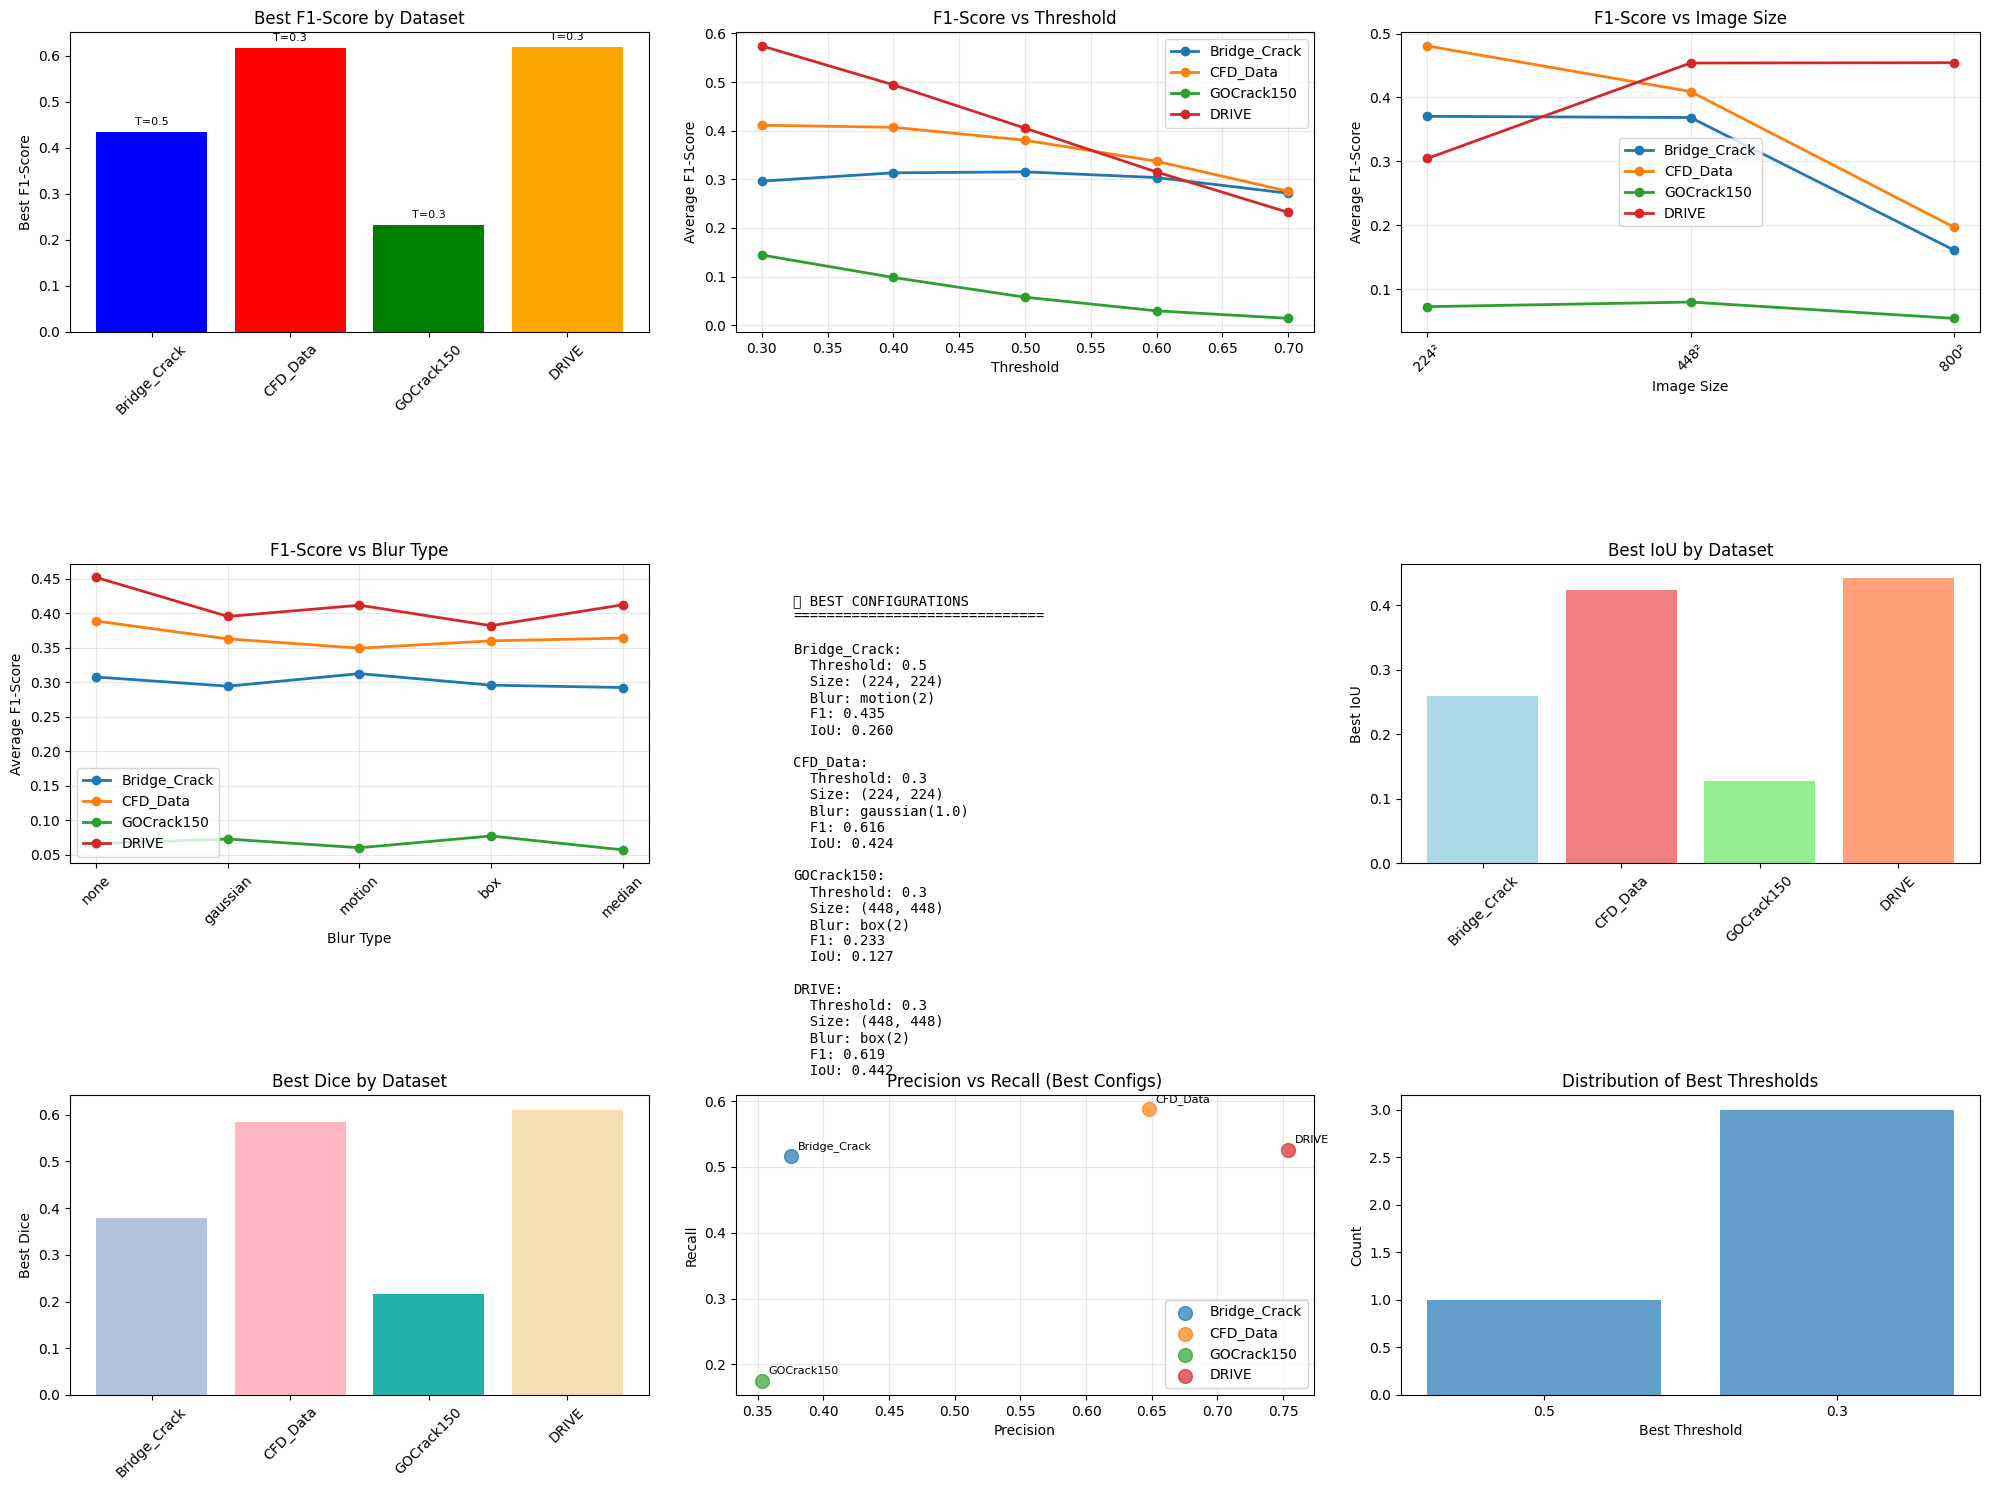

In [46]:
# Plot Grid Search Results
print("📈 Plotting comprehensive grid search results...")

plot_grid_search_results(grid_results)

In [47]:
# Print Detailed Grid Search Summary
print_grid_search_summary(grid_results)


🎯 GRID SEARCH OPTIMIZATION SUMMARY

📊 BRIDGE_CRACK RESULTS:
--------------------------------------------------
🏆 OPTIMAL CONFIGURATION:
  Decision Threshold:    0.5
  Image Resolution:      224 x 224
  Blur Effect:          motion (strength: 2)

📈 PERFORMANCE METRICS:
  F1-Score:             0.4346
  IoU:                  0.2597
  Dice Coefficient:     0.3796
  Accuracy:             0.9589
  Precision:            0.3753
  Recall:               0.5161
  Samples Evaluated:    30

📊 CFD_DATA RESULTS:
--------------------------------------------------
🏆 OPTIMAL CONFIGURATION:
  Decision Threshold:    0.3
  Image Resolution:      224 x 224
  Blur Effect:          gaussian (strength: 1.0)

📈 PERFORMANCE METRICS:
  F1-Score:             0.6165
  IoU:                  0.4241
  Dice Coefficient:     0.5835
  Accuracy:             0.9860
  Precision:            0.6476
  Recall:               0.5882
  Samples Evaluated:    30

📊 GOCRACK150 RESULTS:
-----------------------------------------------

In [48]:
# Apply Best Configurations and Re-evaluate
def apply_best_configurations(model, validation_datasets, grid_results, device):
    """
    Apply the best found configurations to evaluate the model
    """
    print("🎯 Applying Best Configurations for Final Evaluation")
    print("="*60)
    
    final_results = {}
    
    for dataset_name, dataset in validation_datasets.items():
        if dataset_name in grid_results and grid_results[dataset_name]['best_config']:
            best_config = grid_results[dataset_name]['best_config']
            
            print(f"\n📊 Evaluating {dataset_name} with optimal configuration:")
            print(f"  Threshold: {best_config['threshold']}")
            print(f"  Image Size: {best_config['img_size']}")
            print(f"  Blur: {best_config['blur_type']} ({best_config['blur_strength']})")
            
            # Evaluate with full dataset using best configuration
            metrics = evaluate_with_parameters(
                model, dataset,
                threshold=best_config['threshold'],
                img_size=best_config['img_size'],
                blur_type=best_config['blur_type'],
                blur_strength=best_config['blur_strength'],
                device=device,
                max_samples=None  # Use full dataset
            )
            
            if metrics:
                final_results[dataset_name] = {
                    'config': best_config,
                    'metrics': metrics
                }
                
                print(f"  Results (Full Dataset):")
                print(f"    F1-Score:   {metrics['f1_score']:.4f}")
                print(f"    IoU:        {metrics['iou']:.4f}")
                print(f"    Dice:       {metrics['dice']:.4f}")
                print(f"    Accuracy:   {metrics['accuracy']:.4f}")
                print(f"    Precision:  {metrics['precision']:.4f}")
                print(f"    Recall:     {metrics['recall']:.4f}")
                print(f"    Samples:    {metrics['num_samples']}")
    
    return final_results

# Apply best configurations if grid search was run
if 'grid_results' in locals() and grid_results:
    print("🔄 Applying best configurations for final evaluation...")
    final_optimized_results = apply_best_configurations(
        model, val_datasets, grid_results, DEVICE
    )
    
    # Compare with default configuration (threshold=0.5, no blur, 448x448)
    print("\n" + "="*60)
    print("📈 COMPARISON: Optimized vs Default Configuration")
    print("="*60)
    
    for dataset_name in final_optimized_results.keys():
        if dataset_name in val_datasets:
            # Evaluate with default configuration
            default_metrics = evaluate_with_parameters(
                model, val_datasets[dataset_name],
                threshold=0.5,
                img_size=(448, 448),
                blur_type='none',
                blur_strength=0,
                device=DEVICE,
                max_samples=None
            )
            
            optimized_metrics = final_optimized_results[dataset_name]['metrics']
            
            print(f"\n{dataset_name}:")
            print(f"  Metric      | Default  | Optimized | Improvement")
            print(f"  ------------|----------|-----------|------------")
            print(f"  F1-Score    | {default_metrics['f1_score']:.4f}   | {optimized_metrics['f1_score']:.4f}    | {((optimized_metrics['f1_score']/default_metrics['f1_score']-1)*100):+.1f}%")
            print(f"  IoU         | {default_metrics['iou']:.4f}   | {optimized_metrics['iou']:.4f}    | {((optimized_metrics['iou']/default_metrics['iou']-1)*100):+.1f}%")
            print(f"  Dice        | {default_metrics['dice']:.4f}   | {optimized_metrics['dice']:.4f}    | {((optimized_metrics['dice']/default_metrics['dice']-1)*100):+.1f}%")
            print(f"  Accuracy    | {default_metrics['accuracy']:.4f}   | {optimized_metrics['accuracy']:.4f}    | {((optimized_metrics['accuracy']/default_metrics['accuracy']-1)*100):+.1f}%")

else:
    print("❌ Grid search results not found. Please run the grid search first.")

🔄 Applying best configurations for final evaluation...
🎯 Applying Best Configurations for Final Evaluation

📊 Evaluating Bridge_Crack with optimal configuration:
  Threshold: 0.5
  Image Size: (224, 224)
  Blur: motion (2)
  Results (Full Dataset):
    F1-Score:   0.3540
    IoU:        0.1961
    Dice:       0.2949
    Accuracy:   0.9422
    Precision:  0.3402
    Recall:     0.3689
    Samples:    5769

📊 Evaluating CFD_Data with optimal configuration:
  Threshold: 0.3
  Image Size: (224, 224)
  Blur: gaussian (1.0)
  Results (Full Dataset):
    F1-Score:   0.3540
    IoU:        0.1961
    Dice:       0.2949
    Accuracy:   0.9422
    Precision:  0.3402
    Recall:     0.3689
    Samples:    5769

📊 Evaluating CFD_Data with optimal configuration:
  Threshold: 0.3
  Image Size: (224, 224)
  Blur: gaussian (1.0)
  Results (Full Dataset):
    F1-Score:   0.5815
    IoU:        0.3986
    Dice:       0.5539
    Accuracy:   0.9857
    Precision:  0.5780
    Recall:     0.5851
    Samples

In [49]:
# Quick Test: Run a Smaller Grid Search (Optional)
def quick_grid_search_test(model, validation_datasets, device, max_samples=10):
    """
    Run a quick grid search test with reduced parameters for testing
    """
    print("🧪 Running Quick Grid Search Test...")
    print("This is a smaller test with fewer parameters for quick validation.")
    
    # Reduced parameter grids for testing
    thresholds = [0.4, 0.5, 0.6]
    image_sizes = [(224, 224), (448, 448)]
    blur_configs = [('none', 0), ('gaussian', 1.0)]
    
    results = {}
    
    for dataset_name, dataset in validation_datasets.items():
        print(f"\n🔍 Testing {dataset_name}...")
        
        best_score = 0
        best_config = None
        
        for threshold in thresholds:
            for img_size in image_sizes:
                for blur_type, blur_strength in blur_configs:
                    print(f"  Testing: T={threshold}, Size={img_size}, Blur={blur_type}")
                    
                    metrics = evaluate_with_parameters(
                        model, dataset, threshold, img_size,
                        blur_type, blur_strength, device, max_samples
                    )
                    
                    if metrics and metrics['f1_score'] > best_score:
                        best_score = metrics['f1_score']
                        best_config = {
                            'threshold': threshold,
                            'img_size': img_size,
                            'blur_type': blur_type,
                            'blur_strength': blur_strength,
                            'metrics': metrics
                        }
        
        results[dataset_name] = {
            'best_config': best_config,
            'best_score': best_score
        }
        
        if best_config:
            print(f"  ✅ Best: T={best_config['threshold']}, Size={best_config['img_size']}, F1={best_score:.3f}")
    
    return results

# Uncomment and run this for a quick test
# quick_test_results = quick_grid_search_test(model, val_datasets, DEVICE, max_samples=10)
# print("Quick test completed!")

In [ ]:
import json
import os
from datetime import datetime

def save_training_metrics(prefix="training_metrics"):
    """
    Save all training metrics to JSON files in the current directory
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Main training metrics
    main_metrics = {
        'loss_train_hist': loss_train_hist,
        'acc_train_hist': acc_train_hist,
        'loss_valid_hist': loss_valid_hist,
        'acc_valid_hist': acc_valid_hist,
        'iou_valid_hist': iou_valid_hist,
        'dice_valid_hist': dice_valid_hist,
        'epoch_counter': epoch_counter,
        'best_loss_valid': float(best_loss_valid) if 'best_loss_valid' in locals() else None,
        'timestamp': timestamp
    }
    
    # Save main metrics
    main_filename = f"{prefix}_main_{timestamp}.json"
    with open(main_filename, 'w') as f:
        json.dump(main_metrics, f, indent=2)
    print(f"✅ Saved main training metrics to: {main_filename}")
    
    # Save multi-dataset validation metrics if they exist
    if 'multi_val_metrics' in locals() and multi_val_metrics:
        multi_filename = f"{prefix}_multi_val_{timestamp}.json"
        with open(multi_filename, 'w') as f:
            json.dump(multi_val_metrics, f, indent=2)
        print(f"✅ Saved multi-dataset validation metrics to: {multi_filename}")
    
    # Create a summary file with filenames
    summary = {
        'timestamp': timestamp,
        'main_metrics_file': main_filename,
        'multi_val_metrics_file': multi_filename if 'multi_val_metrics' in locals() and multi_val_metrics else None,
        'epochs_completed': epoch_counter,
        'datasets_tracked': list(multi_val_metrics.keys()) if 'multi_val_metrics' in locals() and multi_val_metrics else []
    }
    
    summary_filename = f"{prefix}_summary_{timestamp}.json"
    with open(summary_filename, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"📋 Saved training summary to: {summary_filename}")
    
    return main_filename, multi_filename if 'multi_val_metrics' in locals() and multi_val_metrics else None

In [ ]:
def load_training_metrics(main_filename=None, multi_filename=None, summary_filename=None):
    """
    Load training metrics from JSON files
    
    Args:
        main_filename: Filename for main metrics (if None, will try to find latest)
        multi_filename: Filename for multi-dataset metrics (if None, will try to find latest)
        summary_filename: Filename for summary (if None, will try to find latest)
    """
    global loss_train_hist, acc_train_hist, loss_valid_hist, acc_valid_hist
    global iou_valid_hist, dice_valid_hist, epoch_counter, best_loss_valid, multi_val_metrics
    
    # If no filenames provided, find the latest ones
    if summary_filename is None:
        summary_files = [f for f in os.listdir('.') if f.startswith('training_metrics_summary_') and f.endswith('.json')]
        if summary_files:
            summary_filename = sorted(summary_files)[-1]  # Get latest
            print(f"📋 Found latest summary file: {summary_filename}")
            
            # Load summary to get other filenames
            with open(summary_filename, 'r') as f:
                summary = json.load(f)
            main_filename = summary.get('main_metrics_file')
            multi_filename = summary.get('multi_val_metrics_file')
    
    # Load main metrics
    if main_filename and os.path.exists(main_filename):
        with open(main_filename, 'r') as f:
            main_metrics = json.load(f)
        
        # Restore main training metrics
        loss_train_hist = main_metrics.get('loss_train_hist', [])
        acc_train_hist = main_metrics.get('acc_train_hist', [])
        loss_valid_hist = main_metrics.get('loss_valid_hist', [])
        acc_valid_hist = main_metrics.get('acc_valid_hist', [])
        iou_valid_hist = main_metrics.get('iou_valid_hist', [])
        dice_valid_hist = main_metrics.get('dice_valid_hist', [])
        epoch_counter = main_metrics.get('epoch_counter', 0)
        best_loss_valid = main_metrics.get('best_loss_valid', float('inf'))
        
        print(f"✅ Loaded main training metrics from: {main_filename}")
        print(f"   - Epochs: {epoch_counter}")
        print(f"   - Training loss history: {len(loss_train_hist)} values")
        print(f"   - Validation loss history: {len(loss_valid_hist)} values")
    
    # Load multi-dataset validation metrics
    if multi_filename and os.path.exists(multi_filename):
        with open(multi_filename, 'r') as f:
            multi_val_metrics = json.load(f)
        
        print(f"✅ Loaded multi-dataset validation metrics from: {multi_filename}")
        print(f"   - Datasets: {list(multi_val_metrics.keys())}")
        for dataset, metrics in multi_val_metrics.items():
            if 'loss' in metrics and metrics['loss']:
                print(f"   - {dataset}: {len(metrics['loss'])} epochs")
    
    return main_filename, multi_filename

In [ ]:
def auto_save_metrics_every_n_epochs(n=5):
    """
    Auto-save metrics every N epochs during training
    """
    if epoch_counter % n == 0 and epoch_counter > 0:
        save_training_metrics(f"auto_save_epoch_{epoch_counter}")
        print(f"🔄 Auto-saved metrics at epoch {epoch_counter}")

def list_saved_metrics():
    """
    List all saved training metrics files in current directory
    """
    files = [f for f in os.listdir('.') if f.startswith('training_metrics_') and f.endswith('.json')]
    
    if not files:
        print("❌ No saved training metrics found")
        return
    
    print("📁 Found saved training metrics:")
    summary_files = [f for f in files if 'summary' in f]
    main_files = [f for f in files if 'main' in f]
    multi_files = [f for f in files if 'multi_val' in f]
    
    print(f"   Summary files: {len(summary_files)}")
    for f in sorted(summary_files):
        print(f"     - {f}")
    
    print(f"   Main metrics files: {len(main_files)}")
    print(f"   Multi-dataset files: {len(multi_files)}")

# Example usage:
print("🔧 Training Metrics Save/Load Functions Ready!")
print()
print("Usage examples:")
print("1. Save current metrics:")
print("   save_training_metrics()")
print()
print("2. Load latest metrics:")
print("   load_training_metrics()")
print()
print("3. Load specific metrics:")
print("   load_training_metrics('training_metrics_main_20241207_143022.json')")
print()
print("4. List all saved files:")
print("   list_saved_metrics()")
print()
print("5. Auto-save during training (add to training loop):")
print("   auto_save_metrics_every_n_epochs(5)  # Save every 5 epochs")

In [43]:
def evaluate_model_comprehensive(model, data_loader, criterion, device, threshold=0.5):
    """
    Comprehensive evaluation function that calculates multiple metrics.
    Crack-quality metrics are computed on the line class, while accuracy is multiclass.
    """
    model.eval()
    
    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    total_precision = 0.0
    total_recall = 0.0
    total_f1 = 0.0
    total_accuracy = 0.0
    
    total_tp = 0
    total_fp = 0
    total_tn = 0
    total_fn = 0
    total_correct_pixels = 0
    total_pixels = 0
    
    num_batches = 0
    num_samples = 0
    
    with torch.no_grad():
        for images, masks in data_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            predictions = outputs.argmax(dim=1)
            
            batch_size = images.size(0)
            
            for i in range(batch_size):
                pred_line = (predictions[i] == LINE_CLASS).flatten()
                mask_line = (masks[i] == LINE_CLASS).flatten()
                
                tp = torch.sum((pred_line == 1) & (mask_line == 1)).item()
                fp = torch.sum((pred_line == 1) & (mask_line == 0)).item()
                tn = torch.sum((pred_line == 0) & (mask_line == 0)).item()
                fn = torch.sum((pred_line == 0) & (mask_line == 1)).item()
                
                total_tp += tp
                total_fp += fp
                total_tn += tn
                total_fn += fn
                total_correct_pixels += torch.sum(predictions[i] == masks[i]).item()
                total_pixels += masks[i].numel()
                
                intersection = tp
                union = tp + fp + fn
                iou = intersection / union if union > 0 else 0.0
                total_iou += iou
                
                dice = (2 * tp) / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0.0
                total_dice += dice
                
                precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                total_precision += precision
                
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                total_recall += recall
                
                f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
                total_f1 += f1
                
                accuracy = (predictions[i] == masks[i]).float().mean().item()
                total_accuracy += accuracy
            
            total_loss += loss.item()
            num_batches += 1
            num_samples += batch_size
    
    avg_metrics = {
        'loss': total_loss / num_batches,
        'iou': total_iou / num_samples,
        'dice': total_dice / num_samples,
        'precision': total_precision / num_samples,
        'recall': total_recall / num_samples,
        'f1': total_f1 / num_samples,
        'accuracy': total_accuracy / num_samples
    }
    
    global_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    global_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    global_f1 = (2 * global_precision * global_recall) / (global_precision + global_recall) if (global_precision + global_recall) > 0 else 0.0
    global_iou = total_tp / (total_tp + total_fp + total_fn) if (total_tp + total_fp + total_fn) > 0 else 0.0
    global_dice = (2 * total_tp) / (2 * total_tp + total_fp + total_fn) if (2 * total_tp + total_fp + total_fn) > 0 else 0.0
    global_accuracy = total_correct_pixels / total_pixels if total_pixels > 0 else 0.0
    
    global_metrics = {
        'loss': total_loss / num_batches,
        'iou': global_iou,
        'dice': global_dice,
        'precision': global_precision,
        'recall': global_recall,
        'f1': global_f1,
        'accuracy': global_accuracy
    }
    
    stats = {
        'num_samples': num_samples,
        'num_batches': num_batches,
        'threshold': threshold,
        'confusion_matrix': {
            'true_positives': total_tp,
            'false_positives': total_fp,
            'true_negatives': total_tn,
            'false_negatives': total_fn
        }
    }
    
    return {
        'average_metrics': avg_metrics,
        'global_metrics': global_metrics,
        'statistics': stats
    }

def print_evaluation_results(results, dataset_name="Dataset"):
    """
    Pretty print the evaluation results.
    """
    print(f"\n{'=' * 60}")
    print(f"📊 COMPREHENSIVE EVALUATION RESULTS - {dataset_name}")
    print(f"{'=' * 60}")
    
    global_metrics = results['global_metrics']
    print(f"\n🎯 GLOBAL METRICS (Pixel-level aggregation):")
    print(f"   Loss:      {global_metrics['loss']:.4f}")
    print(f"   IoU:       {global_metrics['iou']:.4f}")
    print(f"   Dice:      {global_metrics['dice']:.4f}")
    print(f"   Precision: {global_metrics['precision']:.4f}")
    print(f"   Recall:    {global_metrics['recall']:.4f}")
    print(f"   F1 Score:  {global_metrics['f1']:.4f}")
    print(f"   Accuracy:  {global_metrics['accuracy']:.4f}")
    
    avg_metrics = results['average_metrics']
    print(f"\n📈 AVERAGE METRICS (Per-image average):")
    print(f"   Loss:      {avg_metrics['loss']:.4f}")
    print(f"   IoU:       {avg_metrics['iou']:.4f}")
    print(f"   Dice:      {avg_metrics['dice']:.4f}")
    print(f"   Precision: {avg_metrics['precision']:.4f}")
    print(f"   Recall:    {avg_metrics['recall']:.4f}")
    print(f"   F1 Score:  {avg_metrics['f1']:.4f}")
    print(f"   Accuracy:  {avg_metrics['accuracy']:.4f}")
    
    stats = results['statistics']
    cm = stats['confusion_matrix']
    print(f"\n📋 STATISTICS:")
    print(f"   Samples:   {stats['num_samples']}")
    print(f"   Batches:   {stats['num_batches']}")
    print(f"   Threshold: {stats['threshold']}")
    
    print(f"\n🔢 CONFUSION MATRIX:")
    print(f"   True Positives:  {cm['true_positives']:,}")
    print(f"   False Positives: {cm['false_positives']:,}")
    print(f"   True Negatives:  {cm['true_negatives']:,}")
    print(f"   False Negatives: {cm['false_negatives']:,}")
    
    print(f"\n{'=' * 60}")

def evaluate_multiple_datasets(model, datasets_dict, criterion, device, threshold=0.5):
    """
    Evaluate model on multiple datasets and return comprehensive results.
    """
    all_results = {}
    
    print(f"🚀 Starting comprehensive evaluation on {len(datasets_dict)} datasets...")
    print(f"📏 Using threshold: {threshold}")
    
    for dataset_name, data_loader in datasets_dict.items():
        print(f"\n⏳ Evaluating {dataset_name}...")
        results = evaluate_model_comprehensive(
            model, data_loader, criterion, device, threshold
        )
        all_results[dataset_name] = results
        print_evaluation_results(results, dataset_name)
    
    return all_results

In [81]:
evaluate_model_comprehensive(model, test_loader, criterion, DEVICE, threshold=0.5)

{'average_metrics': {'loss': 0.055988495548566185,
  'iou': 0.5160038265116144,
  'dice': 0.6748845413964156,
  'precision': 0.6480819870597763,
  'recall': 0.7276138347492002,
  'f1': 0.6748845413964156,
  'accuracy': 0.9910979262088357},
 'global_metrics': {'loss': 0.055988495548566185,
  'iou': 0.5112710905541671,
  'dice': 0.6766106938056883,
  'precision': 0.6391246230843358,
  'recall': 0.7187680260098935,
  'f1': 0.6766106938056883,
  'accuracy': 0.9910979262088359},
 'statistics': {'num_samples': 22,
  'num_batches': 3,
  'threshold': 0.5,
  'confusion_matrix': {'true_positives': 41120,
   'false_positives': 23218,
   'true_negatives': 4335061,
   'false_negatives': 16089}}}